<a href="https://colab.research.google.com/github/ysn9vq-gmu/rqe_tutorials/blob/main/ls_rls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title PDF Edits
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

# Tutorial to Least Squares and Recursive Least Squares applied to parameter estimation.
## Tracking runner's performance

## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique commonly used to perform regression and/or parameter estimation. It achieves this by minimizing the sum of the squared differences between the observed data and predicted values by our model called residuals. The core idea is that smaller squared errors should mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} + \epsilon = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero. This results in the well known normal equations:

$$ \mathbf{A}^T \mathbf{A} \mathbf{x} = \mathbf{A}^T \mathbf{b} $$

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\hat{\mathbf{x}}$ that best satisfies an overdetermined (More measurements than parameters) system of equations.

It is also well known that if $\epsilon$ is measurement noise that is zero-mean and uncorrelated between samples with covariance $\sigma^2 \mathbf{I}$, the **parameter estimate covariance** or **data correlation matrix**, ($\mathbf{A}^T \mathbf{A}$), has a nice statistical relationship of:

$$\text{Cov}(\hat{\mathbf{x}}) = \sigma^2 (\mathbf{A}^T \mathbf{A})^{-1}$$


## Runner Performance Modeling

We chose this scenario because it's intuitive yet rich enough to illustrate core concepts and extend the code naturally to practical estimation problems.

Imagine a scenario where a runner trains daily for a 1000m run. During training, he uses a sophisticated timer to keep a very accurate true time. He wants to know his pace over the 1000m run during competition. However, on competition day, he will not have this sophisticated timer, so 3 coaches volunteered to record his times  for that day and help him during practice. 1 coach will record times between distances (0 to 500) meters, another between distances (500 to 1000) meters, and the last at 1000 meters. (This is so that when practicing, we can pretend we are comparing against the coachs' times with the machine's to evaluate our soon to be proposed estimator)

We want to estimate his pace on competition day, knowing that the runner's strategy is to accelerate slowly in the first half and maintain speed in the second half.

Each of our coaches will measure the observed time. This defines our model:

$$t_{observed,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j$$

Where:
*   $\theta_1$: The model **parameter** representing the runner's pace (seconds per meter) in segment 1 (0-500m).
*   $\theta_2$: The model **parameter** representing the runner's pace (seconds per meter) in segment 2 (500-1000m).
*   $d_{1,j} = \min(d_j, 500)$: The **known feature** being distance the runner traveled in segment 1 when passing coach $j$.
*   $d_{2,j} = \max(0, d_j - 500)$: The **known feature** being distance the runner traveled in segment 2 when passing coach $j$.
*   $\epsilon_j$: Coach $j$'s **measurement error** from timing imprecision and other unmodeled factors.

By estimating $\theta_1$ and $\theta_2$ from the three coaches' noisy time measurements, we can reconstruct the runner's true pace profile for competition day. This does represent a case of model mismatch (discussed further in the next section)—the runner's actual strategy is not a linear function. However, we can approximate the runner's behavior by assuming that over the long distance, he maintains a consistent pace before shifting to a faster pace in the later half. Because our model is linear in its parameters, the problem can be formulated as a linear system suitable for least squares parameter estimation.

### Potential LS reformulations (Beyond this tutorial's scope)

This tutorial focuses on recursive least squares (RLS). In practice, accurate model formulation is a key requirement for good estimation (The other, being good data collection and processing). This section briefly speaks to some ways a problem can be creatively reformulated to find LS solutions, serving as a roadmap to those with different problems:

*   **Modeling with nonlinear parameters:**
  \
  Our piecewise linear model already provides a simple approximation of the runner's acceleration through reparameterization of speed (m/s) instead of pace (s/m). If we designed our model with speed, our equation would be nonlinear.
  \
  $$t_{observed,j} = d_{1,j} / v_1 + d_{2,j} / v_2 + \epsilon_j$$
  \
  A reparameterization of $\theta = 1/v$ results in the same equation, but not without drawbacks (although, you will find in this tutorial we perform this transformation for better explainability). The error associated to the linear $\theta$ parameter would scale nonlinearly after transforming it back to $v$, which has serious consequences if low velocity values change quickly.
  \
  \
  A more accurate nonlinear model would be the **exponential pace model**:
  \
  $$
  \theta(d) = \theta_{ss} + (\theta_0 - \theta_{ss})e^{-\theta_r d}
  $$
  \
  where the runner smoothly transitions from initial pace $\theta_0$ to steady-state pace $\theta_{ss}$ with rate $\theta_r$.
  \
  The cumulative time at distance $d_j$ is:
  $$
  t(d_j) = \theta_{ss} \cdot d_j + \frac{\theta_0 - \theta_{ss}}{\theta_r}(1 - e^{-\theta_r d_j})
  $$
  \
  This model is **nonlinear** in the parameters due to $\theta_r$ appearing in both the exponent and denominator, requiring iterative nonlinear estimation methods.
  \
  \
  Alternatively, we can apply least squares to a **linearized differential equation** formulation. The exponential model satisfies:
  $$
  \theta'(d) = -\theta_r(\theta(d) - \theta_{ss})
  $$
  \
  This reparameterization onto the pace rate provides a physics-based linear approach, though it introduces additional noise through differentiation.


*   **Modeling with nonlinear features:**
  \
  Our piecewise linear model provides a simple approximation of the runner's acceleration. However, a smoother and more realistic model could use **polynomial features** to capture continuous pace changes:
  $$
  t(d_j) = \theta_0 \cdot d_j + \theta_1 \cdot \frac{d_j^2}{2} + \theta_2 \cdot \frac{d_j^3}{3} + \epsilon_j
  $$
  \
  where the pace function $\theta(d) = \theta_0 + \theta_1 d + \theta_2 d^2$ varies smoothly with distance. The features $d_j$, $d_j^2$, and $d_j^3$ are **nonlinear transformations** of the coach positions, but the model remains **linear in the parameters** $(\theta_0, \theta_1, \theta_2)$ and can be solved using standard least squares. This approach captures smooth acceleration and deceleration without requiring nonlinear optimization, providing a middle ground between the simplicity of piecewise linear models and the complexity of fully nonlinear models. However, a drawback to increasing this feature space is that models tend to overfit, and will usually require regularization.
  The kernel-trick can be applied resulting in Kernel Ridge Regression (KRR), which pushes computation and memory burden towards the number of data samples over number of features. Therefore, KRR is used when there are more features (due to mapping to high nonlinearity) than data samples.

*   **Estimating coach-specific timing bias**
  \
  Suppose the primary source of noise in the observed times comes from how each coach captures the split time at their position. We model this by introducing a coach-specific bias term:
  \
  $$
  t_{obs,j} = d_j^{(1)} \cdot \theta_1 + d_j^{(2)} \cdot \theta_2 + b_j + \epsilon_j
  $$
  \
  where $b_j$ captures the consistent timing bias associated with coach $j$ (e.g., one coach consistently starts their stopwatch early, another late). However, introducing a separate bias parameter for each coach often leads to an underdetermined system. With 3 coaches, we would have 5 parameters $\theta_1, \theta_2, b_1, b_2, b_3$, but only 3 measurements from a single run. This requires richer data collection, such as the runner performing multiple runs under different conditions, or having coaches measure multiple runners with known true times to calibrate their biases.

*   **Non-i.i.d. (independent and identically distributed) noise variance**
  \
  Standard least squares is the optimal estimator when measurement noise is Gaussian, independent, and identically distributed across all observations. However, we should expect the coaches to have different accuracies in their timing measurements:
  \
  \
  -- Coach 1 might have faster reaction time (lower variance)
  \
  -- Coach 2 might be less experienced (higher variance)
  \
  \
  When noise variances differ across coaches but are uncorrelated (heteroscedastic noise), **weighted least squares** is more appropriate.

*   **Regularized Least Squares (ridge or lasso)**
  \
  When using high-order polynomial features or many parameters, the system can overfit to noise. Regularization adds a penalty to the least squares objective function to shrink parameter estimates and improve generalization.


### Formulating a linear system (Ax=b)

To apply Least squares, we transform our runner timing model into the standard linear form:

For coach $j$ at position $d_j$:

$$
t_{obs,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j
$$

Where:
- $d_{1,j} = \min(d_j, 500)$ = distance in segment 1 (0-500m)
- $d_{2,j} = \max(0, d_j - 500)$ = distance in segment 2 (500-1000m)
- $\epsilon_j \sim N(0, \sigma)$ , where $\sigma$ would be in seconds

The above system of equations map to a matrix form:

$$
\vec{t}_{\mathrm{obs}} =
\mathbf{A}\vec{\theta}+\vec{\epsilon}
$$

Expanded:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$
<br>

For example, with 3 Coaches at 250m, 750m, and 1000m:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
250 & 0 \\
500 & 250 \\
500 & 500
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$
\
This $\mathbf{A}$ contains the features from all measurements, known as the **Observation model**. The design of this $\mathbf{A}$ matrix is perhaps the most important component to LS formulation.

### Python imports
Below we start this project by including some python imports and creating our dataset by defining parameters and functions of our observation model and simulation.

This code is organized in object oriented design. In short, it is organized so that "objects" can be created, defined by the below "classes", which are used to mix and match and interact with other objects. This is an important framework for generalizabilty and to reduce redundancy, especially for something like LS. Apply the following templates as needed to create your own classes and objects for different problems.


#### Data Generator Class

The below code describes a general data generator. I would say this is the most important and difficult piece to understand for Least Squares as it would be used to create the A matrix and b vector (e.g organize the features to measured outcomes, or data vs labels). For different problems, follow the template layout given in the below template: "DataGenerator" class. The runner class is an example data generator that uses this template. The runner class acts as a very simple example for this tutorial.

Below I give some brief explanation of the important portions of the class:

*   Class specific functions
    *   generate_measurement_features: Defines the features given problem
    *   compute_features: Translates the features to prepare to be applied into the A matrix. Reparameterizations or feature transformations happen here. This very may just pass outputs to the generate_A_matrix().
    *   compute_observation: Your equation to the model. This equation **can** be nonlinear if it can be reparameterized into a linear equation.  
    *   update_parameters: If your parameters are dynamic, this is where you update them.
    *   init(): Defining how many parameters and what parameters will be applied.

*   Generally applicable to all problems functions
    *   generate_A_matrix: Given the feature value of each sensor, stores w.r.t the mth sensor and nth feature in the A matrix, for a given M x N, A matrix.
    *   generate_b_vector: Given measurements of each sensor, stores w.r.t that sensor.
    *   getters: any function with name "get" is for organizational purposes asked to get certain properties from an object.
    *   run_simulation: As described
    *   run_multiple_simulations: As described

At the end of the day, if you have your own data, you don't need this data generator. Your data must either already be from a linear parameter system. Then, **Measurements replace the b vector** and **features replace the A matrix**.

<font color="blue">In document, code is not included</font>

In [3]:
# @title
import numpy as np
# ============================================
# Base Data Generator Class (General)
# ============================================
class DataGenerator:
    """
    General data generator for creating measurement data from a parametric model.
    Can handle any number of parameters and sensors.
    """

    def __init__(self, name, initial_params, noise_std=0.05, random_seed=None):
        """
        Initialize a general data generator.

        Parameters:
        -----------
        name : str
            Generator name/identifier
        initial_params : dict
            Dictionary of initial parameter values
            Example: {'theta_1': 0.1, 'theta_2': 0.09}
        noise_std : float
            Standard deviation of measurement noise
        random_seed : int, optional
            Random seed for reproducibility
        """
        self.name = name
        self.initial_params = initial_params.copy()
        self.current_params = initial_params.copy()
        self.noise_std = noise_std

        if random_seed is not None:
            self.rng = np.random.RandomState(random_seed)
        else:
            self.rng = np.random.RandomState()

        # Storage for simulation runs
        self.num_runs = 0
        self.data_cube = []  # List of (A, b, features) tuples
        self.params_history = []  # Track parameters over time
        self.measurement_features_history = []

    def generate_measurement_features(self, num_sensors):
        """
        Generate measurement features for sensors.
        Must be implemented by subclasses.

        Parameters:
        -----------
        num_sensors : int
            Number of sensors

        Returns:
        --------
        features : array
            Sensor features
        """
        raise NotImplementedError("Subclasses must implement generate_measurement_features()")

    def compute_features(self, features, params):
        """
        Compute feature vector for a given feature and parameters.
        Must be implemented by subclasses.

        Parameters:
        -----------
        features : float
            Measurement feature
        params : dict
            Model parameters

        Returns:
        --------
        features : array
            Feature vector for this feature
        """
        raise NotImplementedError("Subclasses must implement compute_features()")

    def compute_observation(self, features, params):
        """
        Compute true observation at a feature given parameters.
        Must be implemented by subclasses.

        Parameters:
        -----------
        features : float
            Measurement features
        params : dict
            Model parameters

        Returns:
        --------
        observation : float
            True observation value (before noise)
        """
        raise NotImplementedError("Subclasses must implement compute_observation()")

    def update_parameters(self, day):
        """
        Update parameters based on day.
        Can be overridden by subclasses for time-varying behavior.

        Parameters:
        -----------
        day : int
            Current day number (0-indexed)
        """
        # Base class: no change (constant parameters)
        pass

    def generate_A_matrix(self, features):
        """
        Generate design matrix A from measurement features.

        Parameters:
        -----------
        features : array of shape (num_sensors,)
            Measurement features

        Returns:
        --------
        A : array of shape (num_sensors, num_params)
            Design matrix
        """
        num_sensors = len(features)
        num_params = len(self.current_params)
        A = np.zeros((num_sensors, num_params))

        for i, pos in enumerate(features):
            features = self.compute_features(pos, self.current_params)
            A[i, :] = features

        return A

    def generate_b_vector(self, features, params, add_noise=True):
        """
        Generate observation vector b from features and parameters.

        Parameters:
        -----------
        features : array of shape (num_sensors,)
            Measurement features
        params : dict
            Model parameters
        add_noise : bool
            Whether to add measurement noise

        Returns:
        --------
        b : array of shape (num_sensors, 1)
            Observation vector
        """
        num_sensors = len(features)
        b = np.zeros((num_sensors, 1))

        for i, pos in enumerate(features):
            true_obs = self.compute_observation(pos, params)

            if add_noise:
                noise = self.rng.normal(0, self.noise_std)
                observed = true_obs + noise
            else:
                observed = true_obs

            b[i, 0] = observed

        return b

    def run_simulation(self, day, num_sensors, **kwargs):
        """
        Run one simulation and store A matrix and b vector.

        Parameters:
        -----------
        day : int
            Current day number (0-indexed)
        num_sensors : int
            Number of sensors for this run
        **kwargs : dict
            Additional arguments for feature generation

        Returns:
        --------
        A : array of shape (num_sensors, num_params)
            Design matrix
        b : array of shape (num_sensors, 1)
            Observation vector
        features : array of shape (num_sensors,)
            Measurement features
        """
        # Update parameters based on day
        self.update_parameters(day)

        # Generate measurement features
        features = self.generate_measurement_features(num_sensors, **kwargs)
        self.measurement_features_history.append(features)

        # Store parameters for this day
        self.params_history.append({
            'day': day,
            **self.current_params.copy()
        })

        # Generate A matrix and b vector
        A = self.generate_A_matrix(features)
        b = self.generate_b_vector(features, self.current_params)

        # Store this run's data
        self.data_cube.append((A, b, features))
        self.num_runs += 1

        return A, b, features

    def run_multiple_simulations(self, num_days, num_sensors, **kwargs):
        """
        Run multiple simulations over consecutive days.

        Parameters:
        -----------
        num_days : int
            Number of days to simulate
        num_sensors : int
            Number of sensors per run
        **kwargs : dict
            Additional arguments passed to run_simulation
        """
        for day in range(num_days):
            self.run_simulation(day, num_sensors, **kwargs)

    def get_simulation_data(self, day_idx):
        """
        Get A, b, and features for a specific day.

        Parameters:
        -----------
        day_idx : int
            Day index (0 to num_runs-1)

        Returns:
        --------
        A : array
            Design matrix
        b : array
            Observation vector
        features : array
            Measurement features
        """
        if day_idx >= self.num_runs:
            raise IndexError(f"Day {day_idx} not available. Only {self.num_runs} runs performed.")
        return self.data_cube[day_idx]

    def get_all_data(self):
        """
        Get all A and b matrices stacked.

        Returns:
        --------
        A_all : array
            Stacked design matrices
        b_all : array
            Stacked observation vectors
        """
        A_list = [A for A, b, pos in self.data_cube]
        b_list = [b for A, b, pos in self.data_cube]
        return np.vstack(A_list), np.vstack(b_list)

    def __repr__(self):
        param_str = ', '.join([f"{k}={v:.4f}" for k, v in self.current_params.items()])
        return f"DataGenerator(name='{self.name}', runs={self.num_runs}, {param_str})"

#### Runner class

The runner class as described before is an example of applying the template: data generator class.
The below code also creates 3 other runners: constant runner, improving runner, and injured runner, which will be used throughout this tutorial.

Ai-Assisted code likes to include a lot of comments and in function is not actually very large.

<font color="blue">In document, code is not included</font>

In [4]:
# @title

# ============================================
# Runner Class (Specific Implementation)
# ============================================

class Runner(DataGenerator):
    """
    Runner-specific data generator for piecewise linear pace model.
    - 2 parameters: theta_1 (pace in segment 1), theta_2 (pace in segment 2)
    - 3 sensors (coaches) positioned at specific locations
    - Distance range: 0-1000m with boundary at 500m
    - Pace measured in seconds per meter (s/m)
    """

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 noise_std=0.05, random_seed=None):
        """
        Initialize a runner with piecewise linear pace model.
        """
        initial_params = {
            'theta_1': initial_theta_1,
            'theta_2': initial_theta_2
        }
        super().__init__(name, initial_params, noise_std, random_seed)

        # Runner-specific attributes
        self.boundary = 500.0  # meters
        self.total_distance = 1000.0  # meters

    def generate_measurement_features(self, num_sensors=3, last_day=False):
        """
        Generate coach positions for a run.
        - Coach A: randomly between 0 and 500 meters
        - Coach B: randomly between 500 and 1000 meters
        - Coach C: always at 1000 meters
        On last day: fixed at [250, 750, 1000]
        """
        if num_sensors != 3:
            raise ValueError("Runner requires exactly 3 coaches")

        if last_day:
            return np.array([250.0, 750.0, 1000.0])
        else:
            coach_A_pos = self.rng.uniform(0, self.boundary)
            coach_B_pos = self.rng.uniform(self.boundary, self.total_distance)
            coach_C_pos = self.total_distance
            return np.array([coach_A_pos, coach_B_pos, coach_C_pos])

    def compute_features(self, position, params):
        """
        Compute piecewise linear features for a position.

        Parameters:
        -----------
        position : float
            Distance along track (meters)
        params : dict
            Model parameters (not used, features depend only on position)

        Returns:
        --------
        features : array of shape (2,)
            [d1, d2] where:
            - d1 = distance in segment 1 (0-500m)
            - d2 = distance in segment 2 (500-1000m)
        """
        d1 = min(position, self.boundary)
        d2 = max(0, position - self.boundary)
        return np.array([d1, d2])

    def compute_observation(self, position, params):
        """
        Compute cumulative time at a position using piecewise pace model.

        Time = d1 * theta_1 + d2 * theta_2
        where pace is in seconds per meter.

        Parameters:
        -----------
        position : float
            Distance along track (meters)
        params : dict
            Model parameters with keys 'theta_1', 'theta_2'

        Returns:
        --------
        time : float
            Cumulative time at position (seconds)
        """
        theta_1 = params['theta_1']
        theta_2 = params['theta_2']

        features = self.compute_features(position, params)
        d1, d2 = features

        time = d1 * theta_1 + d2 * theta_2
        return time

    def run_simulation(self, day, last_day=False):
        return super().run_simulation(day, num_sensors=3, last_day=last_day)

    def run_multiple_simulations(self, num_days):
        for day in range(num_days):
            self.run_simulation(day, last_day=(day == num_days - 1))

    def __repr__(self):
        return (
            f"Runner(name='{self.name}', runs={self.num_runs}, "
            f"θ₁={self.current_params['theta_1']:.4f} s/m, "
            f"θ₂={self.current_params['theta_2']:.4f} s/m)")


# ============================================
# Specialized Runner Classes
# ============================================

class ConstantRunner(Runner):
    """Runner with constant pace throughout simulation."""

    def update_parameters(self, day):
        # No change - parameters stay constant
        pass


class ImprovingRunner(Runner):
    """Runner with gradually improving pace (pace decreases)."""

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 improvement_rate=0.0002, noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        improvement_rate : float
            Rate at which pace improves per day (pace decreases by this amount)
        """
        super().__init__(name, initial_theta_1, initial_theta_2, noise_std, random_seed)
        self.improvement_rate = improvement_rate

    def update_parameters(self, day):
        # Pace decreases (gets faster) over time
        self.current_params['theta_1'] = (
            self.initial_params['theta_1'] - self.improvement_rate * day
        )
        self.current_params['theta_2'] = (
            self.initial_params['theta_2'] - self.improvement_rate * day * 0.5
        )


class InjuredRunner(Runner):
    """Runner with sudden injury on a specific day, then gradual recovery."""

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 injury_day=10, injury_severity=0.03, recovery_rate=0.0005,
                 noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        injury_day : int
            Day when injury occurs
        injury_severity : float
            How much pace increases (slows down) due to injury (s/m)
        recovery_rate : float
            Rate of recovery per day after injury (s/m per day)
        """
        super().__init__(name, initial_theta_1, initial_theta_2, noise_std, random_seed)
        self.injury_day = injury_day
        self.injury_severity = injury_severity
        self.recovery_rate = recovery_rate
        self.injury_impact = 0.0

    def update_parameters(self, day):
        if day == self.injury_day:
            # Injury occurs - sudden increase in pace (slower)
            self.injury_impact = self.injury_severity
        elif day > self.injury_day:
            # Gradual recovery - injury impact decreases
            self.injury_impact = max(0, self.injury_impact - self.recovery_rate)

        # Apply injury impact to parameters
        self.current_params['theta_1'] = self.initial_params['theta_1'] + self.injury_impact
        self.current_params['theta_2'] = self.initial_params['theta_2'] + self.injury_impact

#### Base Estimator Class

This is the most important class for use on data.

*   def estimator() - is where you apply your estimator equations
\
Examples are spread throughout this tutorial as we walk through how LS, BLS, EBLS, and RLS are applied.
*   def update() - is where you may update applying A and b matrices - for example, when accumulating A and b matrices for Batch LS.


<font color="blue">In document, code is not included</font>

In [5]:
# @title
import numpy as np
class Estimator:
    """
    Base class for parameter estimators.
    Handles history tracking and common functionality.
    """
    def __init__(self, num_params=2):

        self.num_params = num_params

        # History tracking
        self.estimates_history = []
        self.prediction_error_history = []
        self.residual_history = []
        self.day_history = []
        self.true_error_history = []  # Error vs noiseless observations


    def estimator(self,A,B):
        pass

    def update(self, A_new, b_new, day=None):
        """
        Estimate parameters for a single day using least squares.

        Parameters:
        -----------
        A_new : array of shape (num_coaches, 2)
            Design matrix
        b_new : array of shape (num_coaches, 1)
            Observation vector
        day : int, optional
            Day number for tracking
        """
        x_est = self.estimator(A_new, b_new)
        # Compute metrics
        prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)
        # Store results
        self._store_results(x_est, prediction_error, residuals, day)

    def _compute_prediction_error(self, A, b, x_est):
        """
        Compute prediction error and residuals.

        Parameters:
        -----------
        A : array
            Design matrix
        b : array
            Observation vector
        x_est : array
            Estimated parameters

        Returns:
        --------
        prediction_error : float
            Mean absolute prediction error
        residuals : array
            Residuals (b - A @ x_est)
        """
        b_predicted = A @ x_est
        residuals = b - b_predicted
        prediction_error = np.mean(np.abs(residuals))
        return prediction_error, residuals

    def _store_results(self, x_est, prediction_error, residuals, day=None):
        """
        Store estimation results in history.

        Parameters:
        -----------
        x_est : array
            Estimated parameters
        prediction_error : float
            Prediction error
        residuals : array
            Residuals
        day : int, optional
            Day number
        """
        self.estimates_history.append(x_est.copy())
        self.prediction_error_history.append(prediction_error)
        self.residual_history.append(residuals.copy())

        if day is not None:
            self.day_history.append(day)

    def _store_nan_results(self, b_shape, day=None):
        """
        Store NaN results when estimation fails.
        """
        self.estimates_history.append(np.full((self.num_params, 1), np.nan))
        self.prediction_error_history.append(np.nan)
        self.residual_history.append(np.full(b_shape, np.nan))

        if day is not None:
            self.day_history.append(day)

    def get_estimate_history(self):
        # Ensure the history is always returned as a 2D array (num_days, num_params)
        if not self.estimates_history:
            return np.array([]).reshape(0, self.num_params)
        return np.array(self.estimates_history).reshape(-1, self.num_params)

    def get_prediction_error_history(self):
        return np.array(self.prediction_error_history)

    def get_residual_history(self):
        return self.residual_history

    def get_true_error_history(self):
        return np.array(self.true_error_history)

#### Plotting Funcitonality

*   plot_prediction_errors() - Plots prediction errors (mean absolute error) over days for one or more estimators, with options to display both noisy observation errors and true noiseless errors in separate subplots.

*   plot_parameter_estimates() - Visualizes how the two pace parameters (θ₁ for 0-500m and θ₂ for 500-1000m) evolve over time for one or more estimators.

*   plot_pace_comparison() - Compares true vs estimated pace (seconds per meter) across the full distance for a specific day.

*   plot_velocity_comparison() - Similar to pace comparison but shows velocity (meters per second) by taking the reciprocal of pace, making it easier to interpret speed differences between true and estimated models.

*   plot_time_comparison() - Displays cumulative time vs distance for a specific day, comparing how the true and estimated models predict total elapsed time at each point along the 1000m course.

<font color="blue">In document, code is not included</font>

In [6]:
# @title
import matplotlib.pyplot as plt
import numpy as np


def plot_prediction_errors(runner, estimators_dict, show_true_errors=True):
    """
    Plot prediction errors for one or more estimators.
    Can show both noisy observation errors and true (noiseless) errors.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors, true_errors) tuples
    show_true_errors : bool
        If True, show both noisy and true errors in separate subplots
    """
    if show_true_errors:
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    else:
        fig, ax = plt.subplots(figsize=(12, 6))
        axes = [ax]  # Make iterable

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors, true_errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(errors))
        avg_error = np.nanmean(errors)
        avg_true_error = np.nanmean(true_errors)

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        # Plot prediction error (vs noisy observations)
        axes[0].plot(days, errors, marker=marker, linestyle='-', linewidth=2,
                    markersize=3, alpha=0.7,
                    label=f'{name} (avg: {avg_error:.4f} s)', color=color)

        if len(estimators_dict) == 1:
            axes[0].axhline(y=avg_error, color=color, linestyle='--', linewidth=2, alpha=0.5)

        # Plot true error (vs noiseless observations)
        if show_true_errors:
            axes[1].plot(days, true_errors, marker=marker, linestyle='-', linewidth=2,
                        markersize=3, alpha=0.7,
                        label=f'{name} (avg: {avg_true_error:.4f} s)', color=color)

            if len(estimators_dict) == 1:
                axes[1].axhline(y=avg_true_error, color=color, linestyle='--', linewidth=2, alpha=0.5)

    # Format first subplot
    axes[0].set_ylabel('Mean Absolute Error (s)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Prediction Errors vs Noisy Observations',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    if not show_true_errors:
        axes[0].set_xlabel('Day', fontsize=12, fontweight='bold')

    # Format second subplot if showing true errors
    if show_true_errors:
        axes[1].set_xlabel('Day', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Mean Absolute Error (s)', fontsize=12, fontweight='bold')
        axes[1].set_title(f'{runner.name}: True Errors vs Noiseless Observations',
                         fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_parameter_estimates(runner, estimators_dict, window_size=10):
    """
    Plot parameter estimates (theta_1 and theta_2) for one or more estimators
    with rolling standard deviation bounds to show estimate stability.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors, true_errors) tuples
    window_size : int
        Window size for computing rolling standard deviation (default: 10)
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors, true_errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(estimates))

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        # Compute day-to-day variance (std of differences)
        diff_theta1 = np.diff(estimates[:, 0])
        diff_theta2 = np.diff(estimates[:, 1])
        std_theta1 = np.std(diff_theta1)
        std_theta2 = np.std(diff_theta2)

        # Compute rolling std for visualization
        theta1_rolling_std = np.array([
            np.std(estimates[max(0, i-window_size):i+1, 0])
            if i >= window_size else np.std(estimates[:i+1, 0])
            for i in range(len(estimates))
        ])

        theta2_rolling_std = np.array([
            np.std(estimates[max(0, i-window_size):i+1, 1])
            if i >= window_size else np.std(estimates[:i+1, 1])
            for i in range(len(estimates))
        ])

        # Plot theta_1 with std band
        axes[0].plot(days, estimates[:, 0], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=f'{name} (σ_Δ={std_theta1:.6f})', color=color)

        axes[0].fill_between(days,
                            estimates[:, 0] - theta1_rolling_std,
                            estimates[:, 0] + theta1_rolling_std,
                            alpha=0.15, color=color)

        # Plot theta_2 with std band
        axes[1].plot(days, estimates[:, 1], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=f'{name} (σ_Δ={std_theta2:.6f})', color=color)

        axes[1].fill_between(days,
                            estimates[:, 1] - theta2_rolling_std,
                            estimates[:, 1] + theta2_rolling_std,
                            alpha=0.15, color=color)

    axes[0].set_ylabel('θ₁ (0-500m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Parameter Estimates with ±1σ Rolling Std Bounds',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Day', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('θ₂ (500-1000m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



def plot_pace_comparison(runner, estimates, day_idx=-1):
    """
    Plot pace (s/m) comparison for a single estimator on a specific day.
    Shows true piecewise model pace vs estimated piecewise model pace.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute paces
    pace_true = np.where(d < 500, theta_1_true, theta_2_true)
    pace_estimated = np.where(d < 500, theta_1_est, theta_2_est)
    pace_diff = pace_true - pace_estimated

    # Get coach positions
    _, _, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Pace comparison
    axes[0].plot(d, pace_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, pace_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach positions
    for i, pos in enumerate(positions):
        pace_at_pos = theta_1_true if pos < 500 else theta_2_true
        axes[0].scatter(pos, pace_at_pos, s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coaches' if i == 0 else '')

    axes[0].set_ylabel('Pace (s/m)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Pace Comparison (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Pace difference
    axes[1].plot(d, pace_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, pace_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Pace Difference (s/m)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)


    plt.tight_layout()
    plt.show()


def plot_velocity_comparison(runner, estimates, day_idx=-1):
    """
    Plot velocity comparison for a single estimator on a specific day.
    Shows true piecewise model vs estimated piecewise model.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute velocities (velocity = 1/pace)
    pace_true = np.where(d < 500, theta_1_true, theta_2_true)
    velocity_true = 1 / pace_true

    pace_estimated = np.where(d < 500, theta_1_est, theta_2_est)
    velocity_estimated = 1 / pace_estimated

    velocity_diff = velocity_true - velocity_estimated

    # Get coach positions
    _, _, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Velocity comparison
    axes[0].plot(d, velocity_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, velocity_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach positions
    for i, pos in enumerate(positions):
        pace_at_pos = theta_1_true if pos < 500 else theta_2_true
        vel_at_pos = 1 / pace_at_pos
        axes[0].scatter(pos, vel_at_pos, s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coaches' if i == 0 else '')

    axes[0].set_ylabel('Velocity (m/s)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Velocity Comparison (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='lower right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Velocity difference
    axes[1].plot(d, velocity_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, velocity_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Velocity Difference (m/s)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)


    plt.tight_layout()
    plt.show()


def plot_time_comparison(runner, estimates, day_idx=-1):
    """
    Plot cumulative time vs distance for a single estimator on a specific day.
    Shows true piecewise model vs estimated piecewise model.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute cumulative times - TRUE MODEL
    time_true = np.where(d < 500,
                         theta_1_true * d,  # Segment 1
                         theta_1_true * 500 + theta_2_true * (d - 500))  # Segment 2

    # Compute cumulative times - ESTIMATED MODEL
    time_estimated = np.where(d < 500,
                             theta_1_est * d,  # Segment 1
                             theta_1_est * 500 + theta_2_est * (d - 500))  # Segment 2

    time_diff = time_true - time_estimated

    # Get coach positions and observed times
    _, b_obs, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Time comparison
    axes[0].plot(d, time_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, time_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach observations
    for i, pos in enumerate(positions):
        axes[0].scatter(pos, b_obs[i, 0], s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coach Observations' if i == 0 else '')

    axes[0].set_ylabel('Cumulative Time (s)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Time vs Distance (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='upper left')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Time difference
    axes[1].plot(d, time_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, time_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Time Difference (s)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)

    plt.tight_layout()
    plt.show()

#### Simulation Functionality

Below code is what I use to control my simulation runs so that the same desired analysis or plots are not repeated, but intead just calls this function to do so. In this tutorial only the prediction errors and parameter estimates will be plotted and analyzed.

Given a runner profile, a dictionary of estimators, number of simulation days, this will output the final estimates for each pace, the average error for estimating the finishing time, and analysis plots

In [7]:
import numpy as np
def run_estimation_analysis(runner, estimators_dict, num_days, plot_day_idx=-1, show_plots=True, detailed_plots=False):
    """
    Run estimation analysis for a runner using multiple estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object with completed runs
    estimators_dict : dict
        Dictionary mapping estimator names to estimator objects
        Example: {'LS': LeastSquares(), 'Batch LS': BatchLeastSquares()}
    num_days : int
        Number of days to simulate
    plot_day_idx : int
        Day index for velocity/time/pace comparison plots (-1 for last day)
    show_plots : bool
        Whether to display plots

    Returns:
    --------
    results : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    """
    print(f"Running estimation analysis for {runner.name}...")
    print(f"Number of days: {num_days}")
    print(f"Estimators: {list(estimators_dict.keys())}")

    # Run all estimators day by day
    for day in range(num_days):
        A_curr, b_curr, positions = runner.get_simulation_data(day)

        for name, estimator in estimators_dict.items():
            # Update estimator with noisy observations
            estimator.update(A_curr, b_curr, day=day)

            # Compute error vs true (noiseless) observations
            estimates = estimator.get_estimate_history()
            latest_estimate = estimates[-1].reshape(-1, 1)

            # Get true parameters and compute true observations
            true_params = runner.params_history[day]
            b_true = np.array([[runner.compute_observation(pos, true_params)]
                              for pos in positions])

            # Compute predictions and error vs truth
            b_pred = A_curr @ latest_estimate
            true_error = np.mean(np.abs(b_true - b_pred))

            # Store in estimator
            estimator.true_error_history.append(true_error)

    # Collect results
    results = {}
    for name, estimator in estimators_dict.items():
        estimates = estimator.get_estimate_history()
        errors = estimator.get_prediction_error_history()
        true_errors = estimator.get_true_error_history()
        results[name] = (estimates, errors, true_errors)

        # Print summary
        print(f"\n{name}:")
        print(f"  Final θ₁: {estimates[-1, 0]:.4f} s/m")
        print(f"  Final θ₂: {estimates[-1, 1]:.4f} s/m")
        print(f"  Avg Prediction Error: {np.mean(errors):.4f} s")
        print(f"  Avg True Error (vs noiseless obs):   {np.mean(true_errors):.4f} s")

    # Generate plots if requested
    if show_plots:
        print("\nGenerating plots...")

        # Plot comparisons across all estimators
        plot_prediction_errors(runner, results, show_true_errors=True)
        plot_parameter_estimates(runner, results)
    if detailed_plots:
      # Plot detailed analysis for each estimator
      for name, (estimates, errors, true_errors) in results.items():
          print(f"  Plotting {name}...")
          plot_pace_comparison(runner, estimates, day_idx=plot_day_idx)
          plot_velocity_comparison(runner, estimates, day_idx=plot_day_idx)
          plot_time_comparison(runner, estimates, day_idx=plot_day_idx)

    return results

###Runners Initialization

We will keep track of 3 different runners. Where the runners keep two constant paces in s/m from 0 to 500m and 500m to 1000m. We will have the runners perform 100 runs, once per day. Runner A will keep same parameters. Runner B will **improve** ( the theta parameters increase slowly ). Runner C have an injury but will slowly recover. ( Theta parameters will decrease drastically on a particular day, but slowly increase.


I highly recommend going back to this portion here and experiment with the runners' functionality

In [8]:
# @title
num_days = 100
noise_std = 0.15 # Human reaction timing offset maybe about 0.15 seconds std.

# Create three runners with different behaviors
runner_A = ConstantRunner(
    name="Runner A (Constant)",
    initial_theta_1=0.125,  # 0.125 s/m = 8 m/s
    initial_theta_2=0.100,  # 0.100 s/m = 10 m/s
    noise_std=noise_std,
    random_seed=42
)

runner_B = ImprovingRunner(
    name="Runner B (Improving)",
    initial_theta_1=0.140,
    initial_theta_2=0.110,
    noise_std=noise_std,
    improvement_rate=0.0002,  # Improves pace by 0.0002 s/m per day
    random_seed=43
)

runner_C = InjuredRunner(
    name="Runner C (Injured)",
    initial_theta_1=0.125,
    initial_theta_2=0.100,
    noise_std=noise_std,
    injury_day=10,
    injury_severity=0.04,  # Pace increases by 0.04 s/m (slows down)
    recovery_rate=0.0004,  # Recovers 0.0004 s/m per day
    random_seed=44
)

# Perform runs
print("Simulating 100 days of training...")
runner_A.run_multiple_simulations(num_days)
runner_B.run_multiple_simulations(num_days)
runner_C.run_multiple_simulations(num_days)

Simulating 100 days of training...


## Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's pace at each distance band for each day:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$


In [9]:
import numpy as np
import matplotlib.pyplot as plt

class LeastSQ(Estimator):
    """
    Daily Least Squares estimator.
    Estimates parameters independently for each day using standard LS.
    """

    def __init__(self,num_params=2):
        """Initialize the least squares estimator."""
        super().__init__(num_params=num_params)
    def estimator(self,A,B):
        # Solve least squares
        x_est = np.linalg.inv(A.T @ A) @ A.T @ B
        return x_est

###LS Simulation on Runner A.

Running estimation analysis for Runner A (Constant)...
Number of days: 100
Estimators: ['LS']

LS:
  Final θ₁: 0.1251 s/m
  Final θ₂: 0.0996 s/m
  Avg Prediction Error: 0.0508 s
  Avg True Error (vs noiseless obs):   0.0975 s

Generating plots...


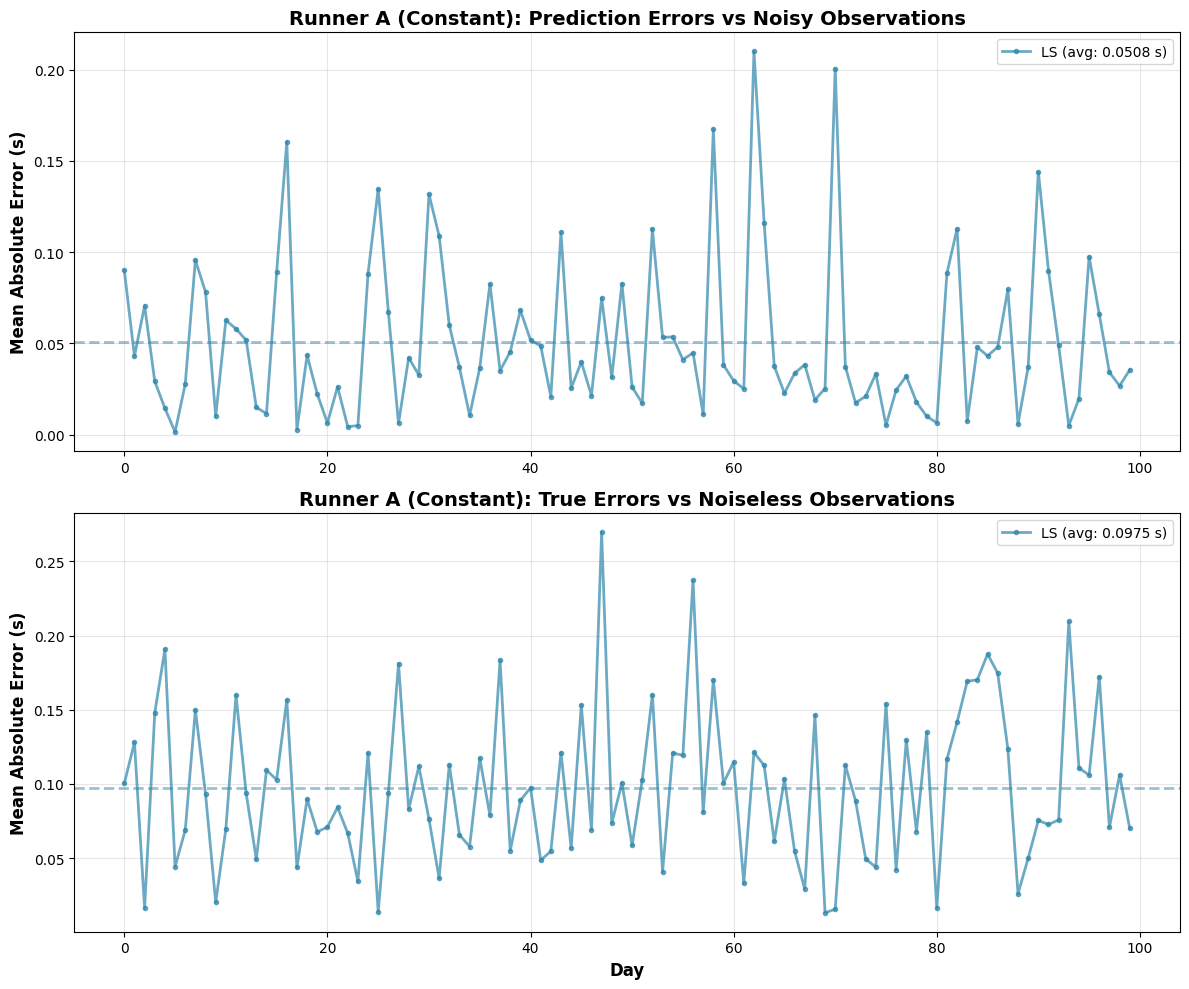

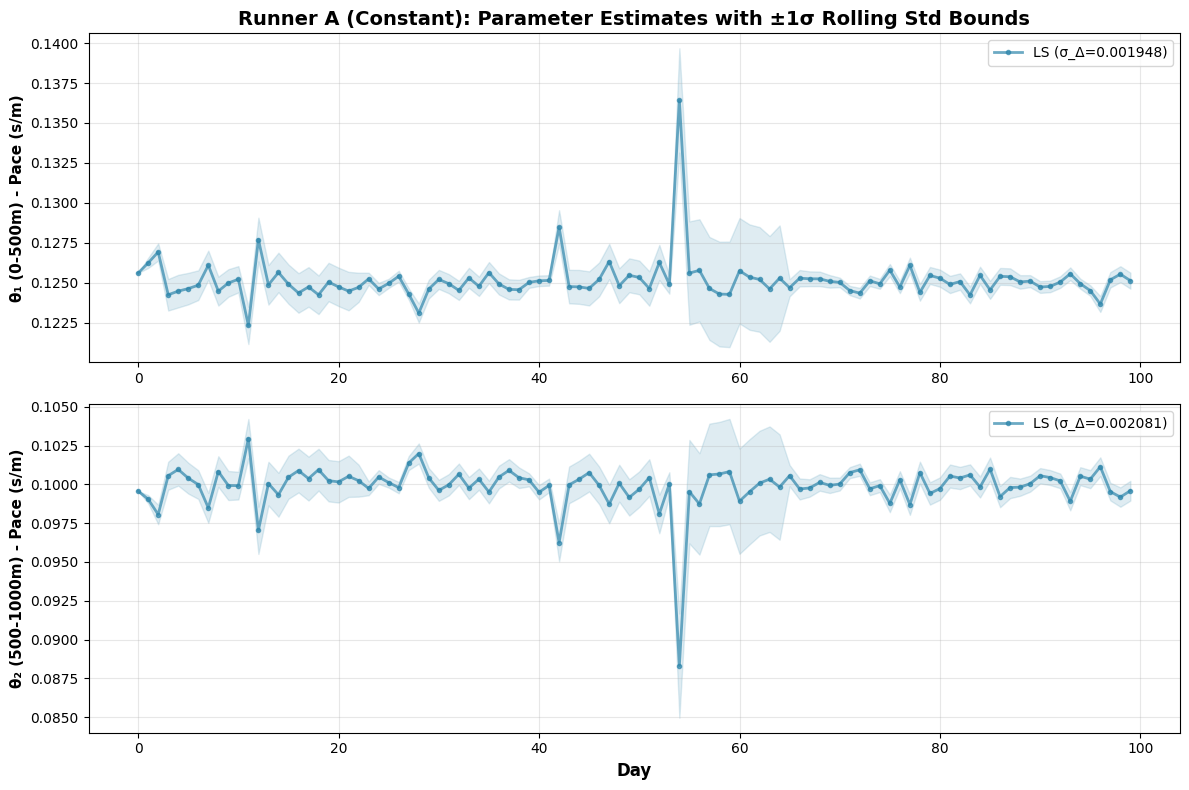

  Plotting LS...


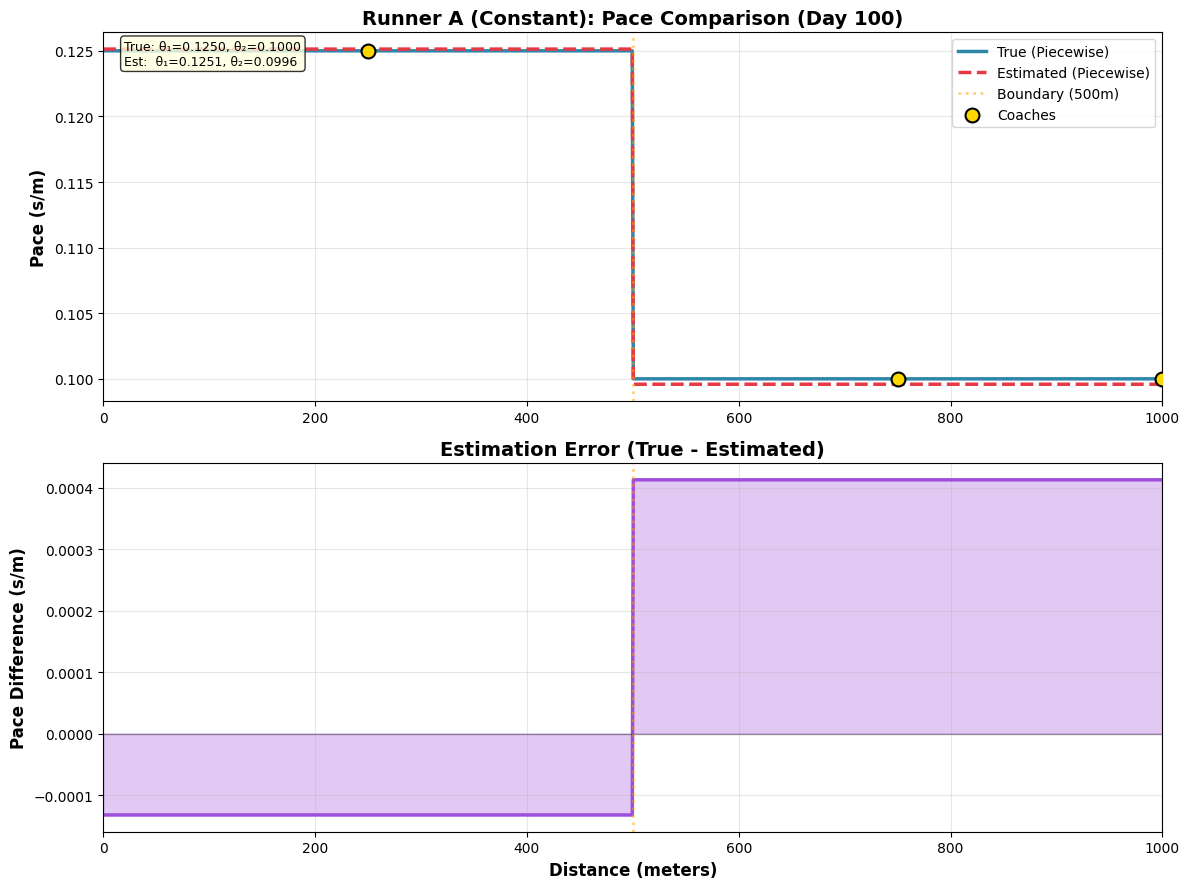

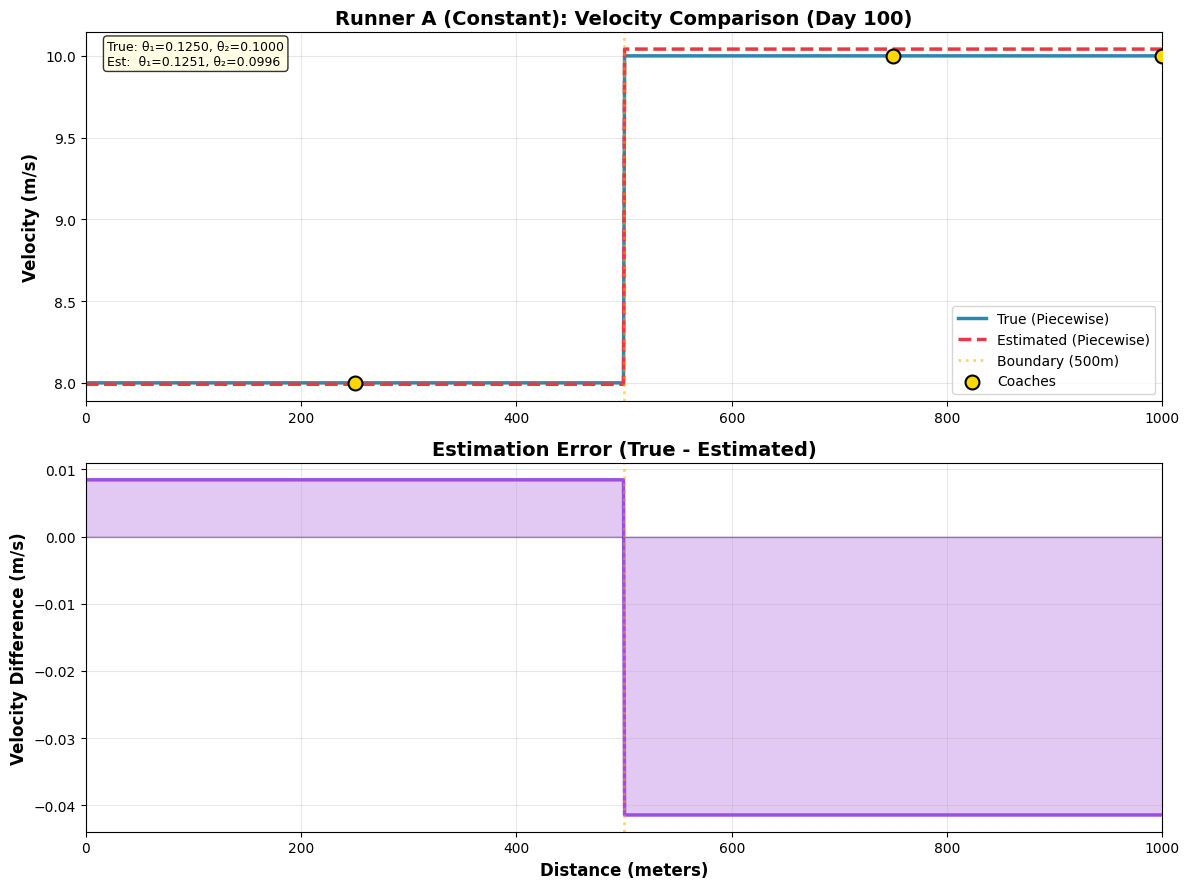

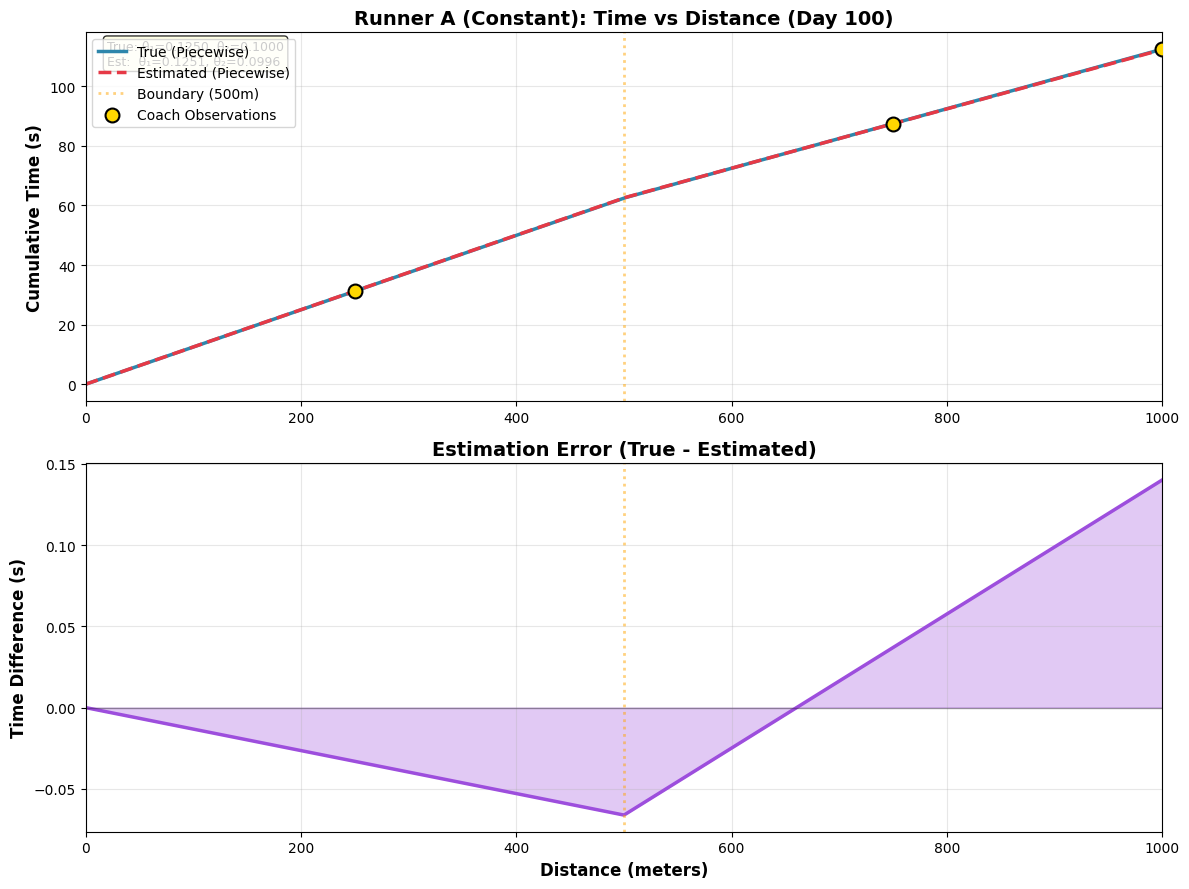

In [10]:
# Setup
num_days = 100

# Define estimators to compare
estimators_A = {
    'LS': LeastSQ()
}
# Run analysis for Runner A
results_A = run_estimation_analysis(
    runner=runner_A,
    estimators_dict=estimators_A,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True,
    detailed_plots=True)


### Brief LS Results analysis

If we assume all coaches have a 0.15s measuring error std, it seems we can expect on average, an error of 0.09s from the true time on competition day! Seems great, but what about the parameter estimates? How well are we tracking his pace?

## Batch Least Squares for Runner Timing

While the single-day LS provides an immediate estimate, its parameter estimates are often noisy and inaccurate due to limited data. What if we want to use all the past data to get a more complete estimate of the runner's pace?

This is where Batch Least Squares comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters are relatively constant over the batch period.

### Mathematical Formulation

Suppose we collect observations over $n$ days. On each day $k$, we have $J$ coaches (in our case, $J=3$) measuring split times at different positions.

**For day $k$, we have a block of equations:**

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix}_k
=
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}_k
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix}_k
+
\begin{bmatrix}
\epsilon_{1} \\
\epsilon_{2} \\
\epsilon_{3}
\end{bmatrix}_k
$$

Or more compactly: $\mathbf{t}_k = \mathbf{A}_k \boldsymbol{\theta} + \boldsymbol{\epsilon}_k$.

**Dimensions:**
- Each $\mathbf{t}_k$: $(3 \times 1)$ — 3 coaches' observations on day $k$
- Each $\mathbf{A}_k$: $(3 \times 2)$ — 3 coaches' position features on day $k$

---
### Optimization problem

Our goal is to solve this optimization problem, minimizing the sum of squared residuals across all $n$ days:

$$
\hat{\boldsymbol{\theta}} = \underset{\boldsymbol{\theta}}{\operatorname{argmin}} \sum_{k=1}^{n} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$$


If we recognize a property that $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $.

$$\hat{\boldsymbol{\theta}} = \underset{\boldsymbol{\theta}}{\operatorname{argmin}} \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2
$$

Where:
$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_n \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{t}_1 \\ \mathbf{t}_2 \\ \vdots \\ \mathbf{t}_n \end{bmatrix} $$


**Stacking all $n$ days together for Simulation:**

$$
\begin{bmatrix}
\mathbf{t}_1 \\
\mathbf{t}_2 \\
\vdots \\
\mathbf{t}_n
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{A}_1 \\
\mathbf{A}_2 \\
\vdots \\
\mathbf{A}_n
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix}
+
\begin{bmatrix}
\boldsymbol{\epsilon}_1 \\
\boldsymbol{\epsilon}_2 \\
\vdots \\
\boldsymbol{\epsilon}_n
\end{bmatrix}
$$

**Dimensions:**
- Stacked system: $(3n \times 1) = (3n \times 2) \cdot (2 \times 1)$
---
###Key insights

We don't need to know how to induce optimization proofs, but just that when we stack observation matrices in BLS, the problem reduces to standard LS, which we can solve directly using the normal equations.

The coach positions change randomly each day, so each $\mathbf{A}_k$ is different. This is important for BLS and LS - if the "rows" in $\mathbf{A}_k$ are the same, but $\mathbf{t}_k$ are different due to random noise, our normal equations will collapse this as an average over all the $\mathbf{A}_k$. It would be a great linear algebra exercise to prove this.




### Creating a Batch LS

Below is the BLS equation.
It simply changes the update function to stack up all the previous A and b variables.
It applies the same estimator as before, in this case, the LeastSQ estimator

In [11]:
class BatchLeastSQ(LeastSQ):
    """
    Batch Least Squares estimator.
    Accumulates data across days and applies least squares to accumulated data.
    """
    def __init__(self,num_params=2):
        super().__init__(num_params=num_params)

        # Accumulated rows as lists
        self._A_rows = []
        self._b_rows = []
        self._rows_per_day = []  # Track rows added each day

    def update(self, A_new, b_new, day=None):
        """
        Accumulate new data and estimate parameters using batch least squares.
        """

        # Extend with new rows
        self._A_rows.extend(A_new)
        self._b_rows.extend(b_new)
        self._rows_per_day.append(len(A_new)) # EWLS extension require this information

        # Convert to arrays
        A_accum = np.array(self._A_rows)
        b_accum = np.array(self._b_rows)

        # Use parent's estimator method on accumulated data
        x_est = self.estimator(A_accum, b_accum)

        # Compute metrics on current data
        prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)

        # Store results
        self._store_results(x_est, prediction_error, residuals, day)

### Run and compare LS and BLS simulation on Runner A - no improvements

The following simulation applies both estimators to runner A, who shows no improvements as days progress

Running estimation analysis for Runner A (Constant)...
Number of days: 100
Estimators: ['LS', 'Batch LS']

LS:
  Final θ₁: 0.1251 s/m
  Final θ₂: 0.0996 s/m
  Avg Prediction Error: 0.0508 s
  Avg True Error (vs noiseless obs):   0.0975 s

Batch LS:
  Final θ₁: 0.1250 s/m
  Final θ₂: 0.1001 s/m
  Avg Prediction Error: 0.1118 s
  Avg True Error (vs noiseless obs):   0.0312 s

Generating plots...


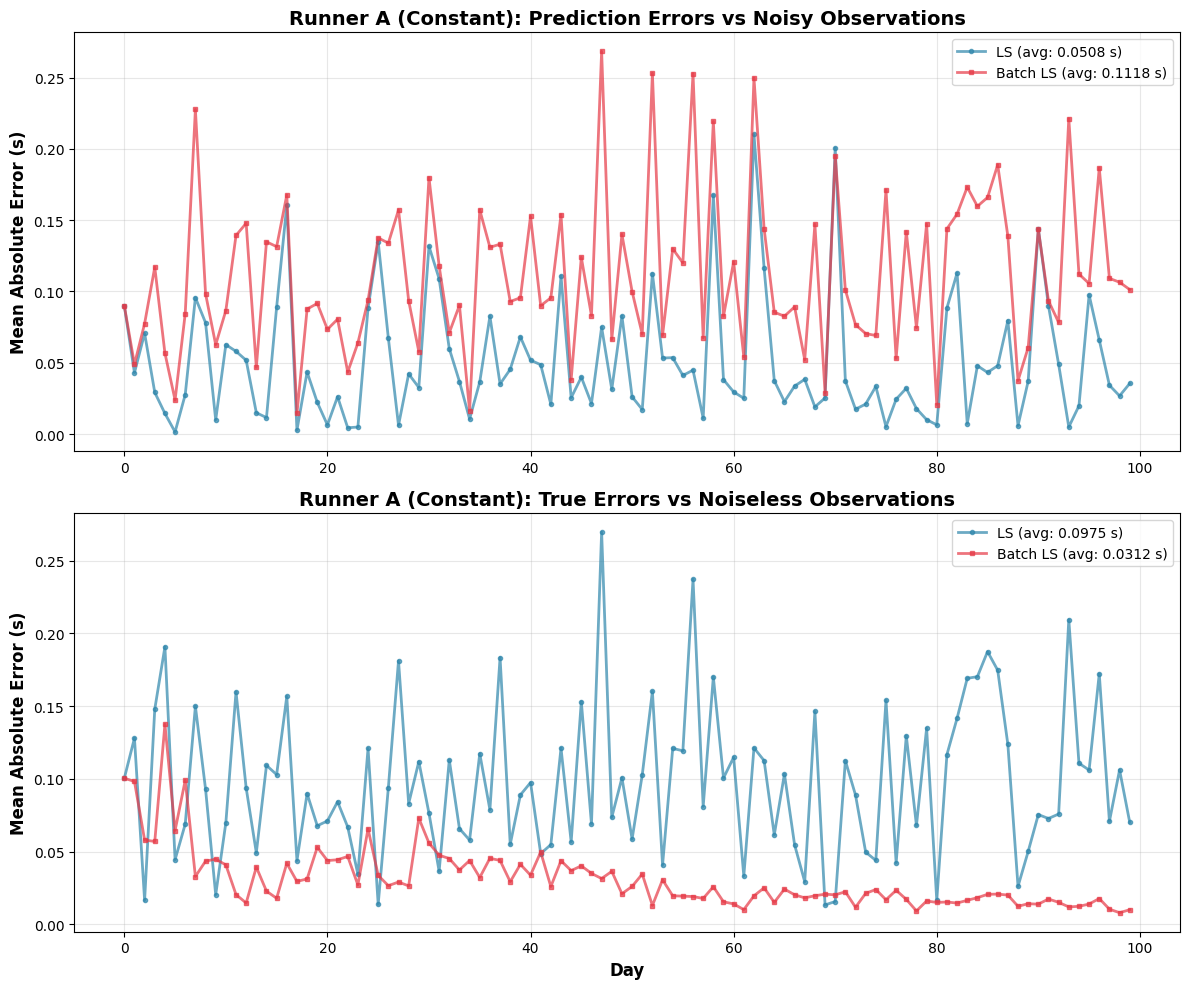

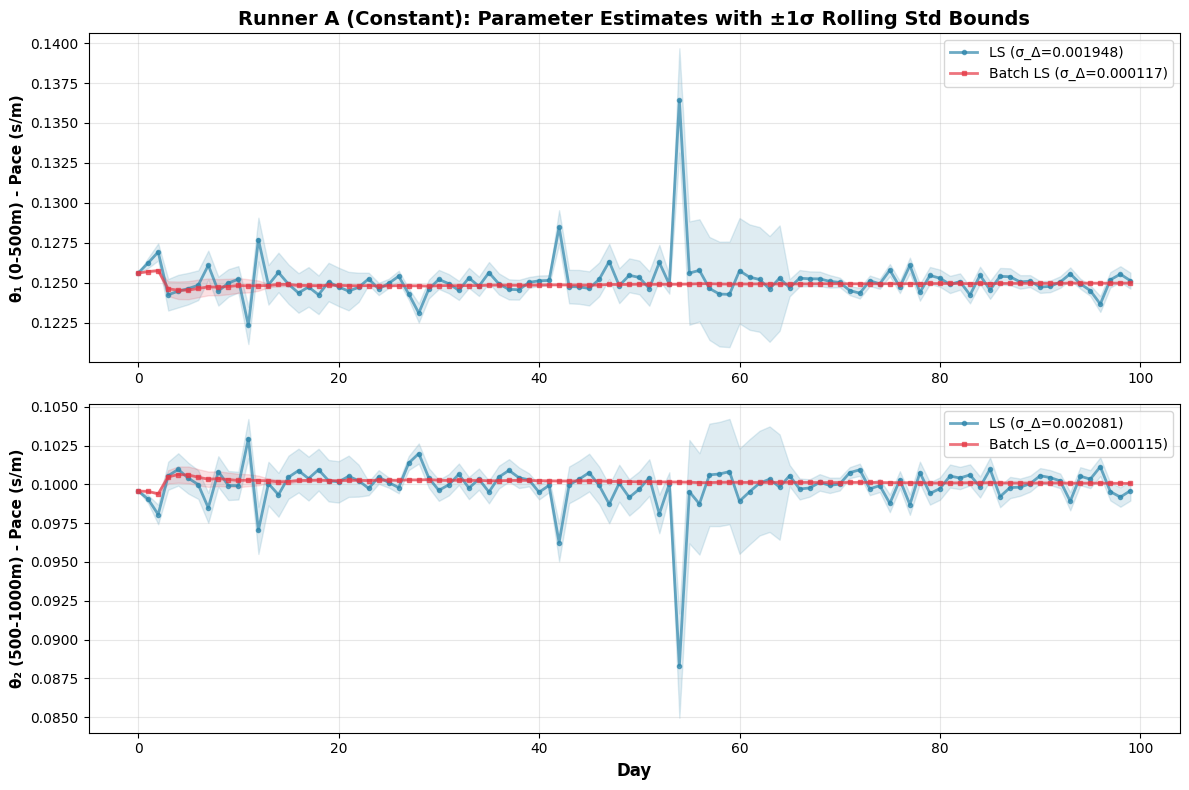

In [12]:
# Setup
num_days = 100

# Define estimators to compare
estimators_A = {
    'LS': LeastSQ(),
    'Batch LS': BatchLeastSQ()
}
# Run analysis for Runner A
results_A = run_estimation_analysis(
    runner=runner_A,
    estimators_dict=estimators_A,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

###Batch LS vs LS analysis for Runner A

1. Why is the absolute average measurement prediction error higher on BLS than LS, if BLS has a better parameter estimate?

    - **Prediction error** is the error between the noisey measurement and our measurement estimate.
    - **True error** is the error between the "ground truth" and our measurement estimate.  

    - LS calculates parameter estimates and measurement errors on only 1 sample of data - e.g for exactly that one day of running and will try to fit to that noisey measurement. BLS applies LS over the whole dataset. BLS is like a very overdetermined LS equation. The same 3 coaches are repeating new measurements ( positioned at different locations between 0 and 1000 ) throughout the 100 days of running.

    - If a true resource exists, we can compare between the not noisy true time and our estimated time. We can see that the Batch Least Sq outperforms the LS in this case.
        - However, in practice, we don't always have this ground truth to compare with!

2. Which estimator should we use?

    - In practice, we may not have this true error plot. However, we are able to track our estimated parameters.
    
    - IF we know that the parameter is stable, we should use BLS.

Conclusions:

1. BLS obtains a more accurate and stable parameter estimate over runs.

2. It does not mean BLS obtains a more accurate measurement estimate with current values.

3. If we were to predict the measurement using previous parameter estimates, we have more confidence that BLS will be more accurate.

    - This would be proven by calculating a cross validation score between previous runs by taking previously estimate parameters and testing these parameters to new runs, and calculate errors.

###Run and compare LS and BLS simulation on Runner B - Improving runner

The following simulation applies both estimators to runner B, who shows improvements as days progress

Running estimation analysis for Runner B (Improving)...
Number of days: 100
Estimators: ['LS', 'Batch LS']

LS:
  Final θ₁: 0.1209 s/m
  Final θ₂: 0.0995 s/m
  Avg Prediction Error: 0.0616 s
  Avg True Error (vs noiseless obs):   0.0912 s

Batch LS:
  Final θ₁: 0.1299 s/m
  Final θ₂: 0.1053 s/m
  Avg Prediction Error: 2.7185 s
  Avg True Error (vs noiseless obs):   2.7149 s

Generating plots...


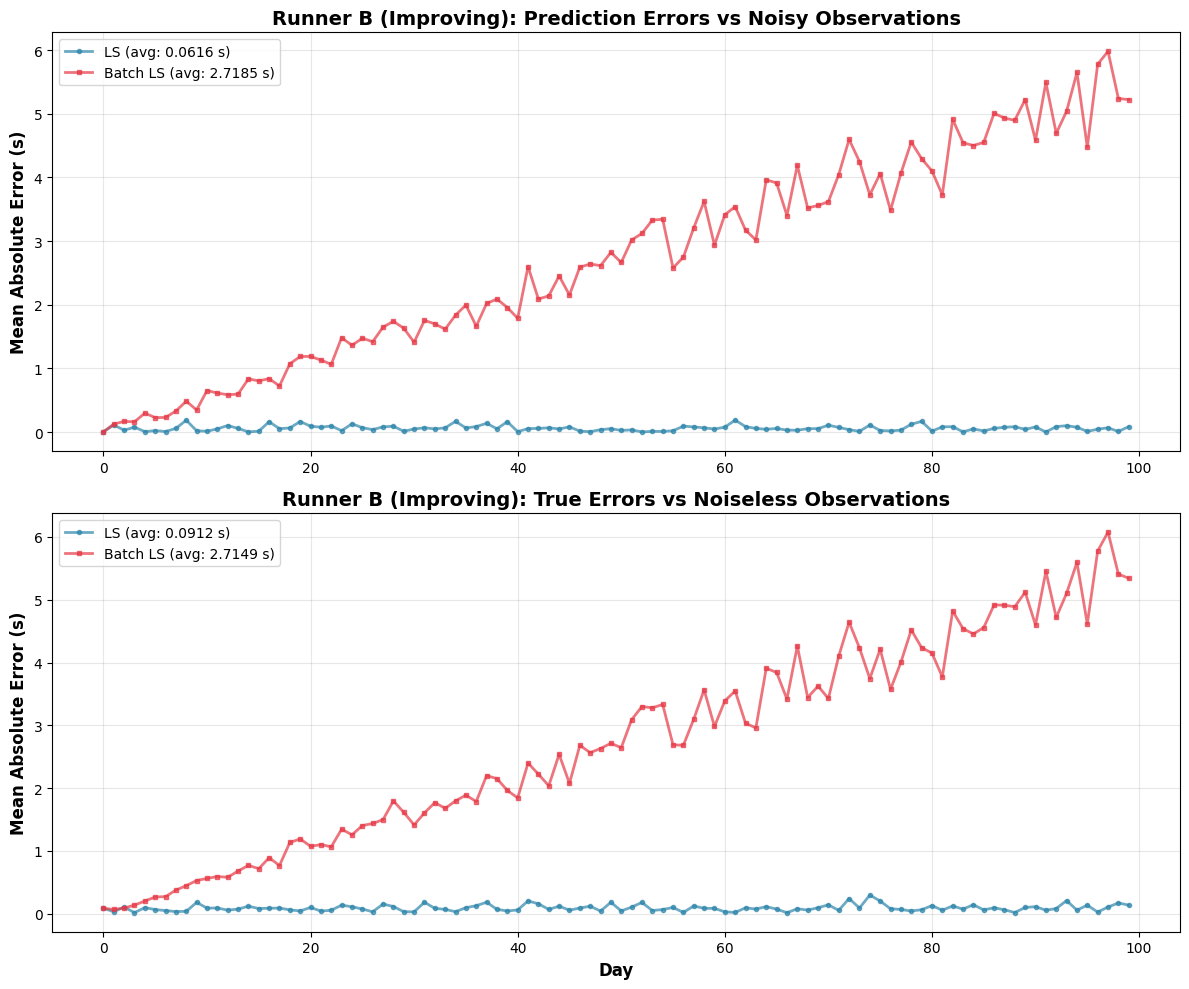

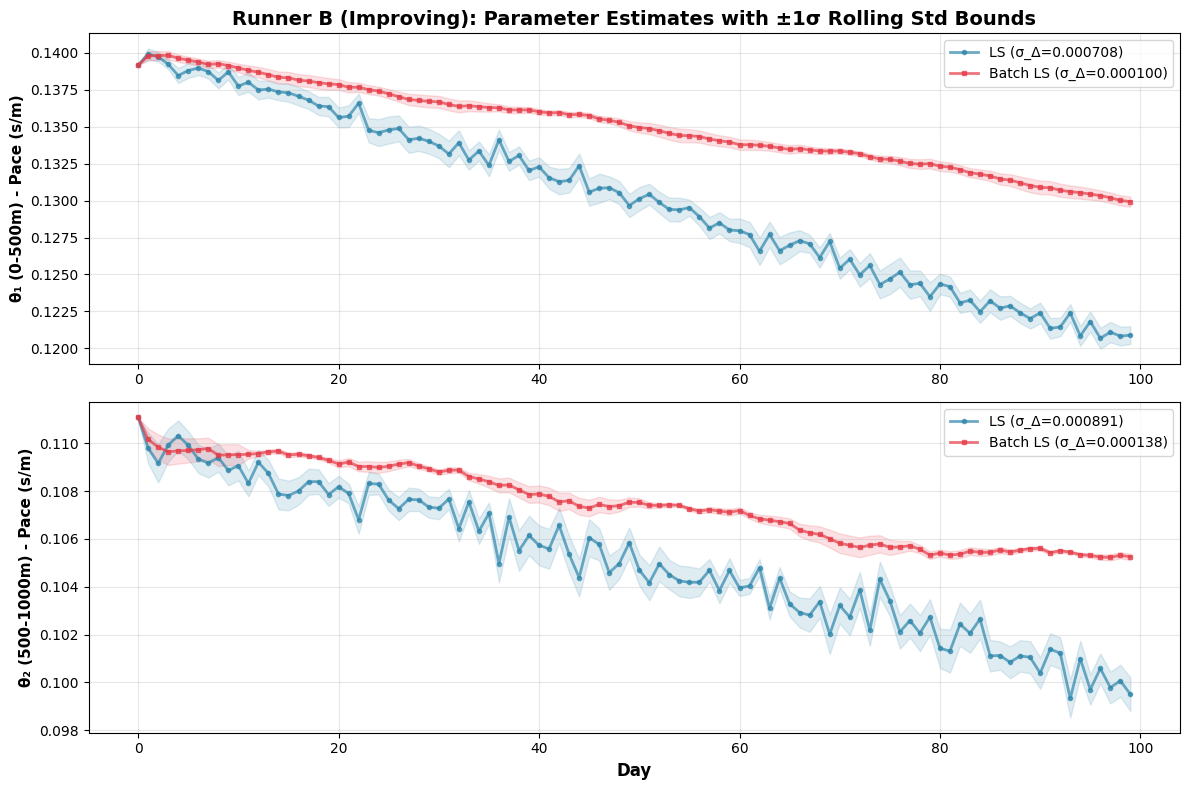

In [13]:
# Setup
num_days = 100

# Run analysis for Runner B (create new estimators)
estimators_B = {
    'LS': LeastSQ(),
    'Batch LS': BatchLeastSQ()
}

results_B = run_estimation_analysis(
    runner=runner_B,
    estimators_dict=estimators_B,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True
)

# Access results later
estimates_ls_A, errors_ls_A, true_errors_ls_A = results_A['LS']
# Can plot specific things later, e.g.,
# plot_velocity_comparison(runner_A, estimates_ls_A, day_idx=50)

### Analysis for Runner B - improving runner

# LS vs BLS Analysis: Evolving Runner Performance

1. What happened? BLS absolutely failed!

    - BLS assumes the parameters are **constant across all observations**. When stacking all days into one system, it finds a single "best fit" parameter across the entire time period. Since the runner is improving (parameters decreasing over time), BLS produces an averaged estimate that doesn't accurately represent any specific day.

    - In contrast, **LS works well** because it estimates parameters **independently for each day** using only that day's observations. It naturally adapts to the evolving state without assuming parameters stay constant.


2. Which estimator should we use?

    - For evolving systems with noisy data, consider **sequential methods** discussed next

Conclusions

1. **LS handles evolving states** by estimating independently each day.
2. **BLS cannot handle evolving states**. It assumes static parameters and produces a poor compromise estimate when applied to time-varying systems.

## Sliding window BLS

In our previous runner estimators, we've assumed that the runner's pace parameters remain constant over time. However, this assumption often fails in practice—runners typically improve with training, or may experience sudden performance drops due to injury. To track these changes, one approach is to use a **sliding window** that applies batch least squares to only the most recent days.

### Creating a sliding window BLS

Below is the sliding window BLS equation.
It simply changes the update function to remove previous stacks when a new observation is given, once the stack is over a set limit.
It applies the same BLS estimator as before.

In [14]:
class SlidingBatchLeastSQ(BatchLeastSQ):
    """
    Sliding Batch Least Squares estimator.
    Accumulates data across a window of measurements and applies least squares to accumulated data.
    """
    def __init__(self,m_window_size=None, num_params=2):
        super().__init__(num_params=num_params)

        self._day_count = 0
        self.m_window_size = m_window_size  # Number of days to keep

    def update(self, A_new, b_new, day=None):
        """
        Accumulate new data with sliding window by days.
        """
        # Extend with new rows
        self._A_rows.extend(A_new) # inherited from BLS
        self._b_rows.extend(b_new) # inherited from BLS
        self._rows_per_day.append(len(A_new)) # inherited from BLS
        self._day_count += 1

        # Calculate start day index for window
        if self.m_window_size is not None:
            start_day_idx = max(0, self._day_count - self.m_window_size)
        else:
            start_day_idx = 0

        # Calculate how many rows to skip
        rows_to_skip = sum(self._rows_per_day[:start_day_idx])

        # Convert to arrays (slice from start of window)
        A_accum = np.array(self._A_rows[rows_to_skip:])
        b_accum = np.array(self._b_rows[rows_to_skip:])

        # Estimate and store
        x_est = self.estimator(A_accum, b_accum)
        prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)
        self._store_results(x_est, prediction_error, residuals, day)

## Exponential Weighted Least Squares (EWLS)

A limitation of the sliding window is that all days within the window are weighted equally. If the runner's performance changes gradually, giving more weight to recent measurements can improve tracking accuracy. **Exponentially weighted least squares (EWLS)** accomplishes this by exponentially decaying the influence of older data, allowing the estimator to adapt smoothly to time-varying parameters.

---
### EWLS Formulation

A Weighted LS (WLS) objective function minimizes the sum of squared weighted residuals similar to that as BLS, except with the added term $w$, for $k$th run:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{n} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})_{stack}^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b})_{stack} $$

Solving for the formulation from the objective function closed-form solution, we can get the closed form solution for WLS as:

$$\hat{\mathbf{x}}_{WLS} = \left(\mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack}\right)^{-1} \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack}$$


Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal, where each diagonal element corresponds to the weight of the respective $k$th stacked observation:

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_n) = \begin{bmatrix}
w_{n-1} & 0 & \dots & 0 \\
0 & w_{n-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & w_{0}
\end{bmatrix} $$
\
\
However, for EWLS these weights exponentially decay for older observations by $\lambda^k$, for $0 < \lambda < 1$. We can see if $\lambda = 1$, this is equivalent to BLS.

$$ \mathbf{W}_{EWLS} = \operatorname{diag}(w_1, w_2, \dots, w_n) = \begin{bmatrix}
\lambda^{n-1} & 0 & \dots & 0 \\
0 & \lambda^{n-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} $$

Instead of constructing another large matrix, because this matrix is diagonal, we can alternatively apply the following weights as scaling factors to the stacked $\mathbf{A}_k$ matrices:

$$
\mathbf{W}_{EWLS} \mathbf{A}_{stack} =
\begin{bmatrix}
\lambda^{n-1} \mathbf{A}_1 \\
\lambda^{n-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_n
\end{bmatrix}, \quad
\mathbf{W}_{EWLS} \mathbf{t}_{stack} =
\begin{bmatrix}
\lambda^{n-1} \mathbf{t}_1 \\
\lambda^{n-2} \mathbf{t}_2 \\
\vdots \\
\lambda^{0} \mathbf{t}_n
\end{bmatrix}
$$



### Creating a EWLS

Below is the EWLS equation.
It simply changes the estimator function for BLS, so that after it stacks up measurements, it applies the weights.

In [15]:
class ExpWeightedLeastSQ(BatchLeastSQ):
    """
    Exponentially Weighted Least Squares estimator.
    """
    def __init__(self, EWLS_lambda=0.95, num_params=2):
        super().__init__(num_params=num_params)
        self.EWLS_lambda = EWLS_lambda

    def estimator(self, A, b):
        # Build weight vector
        C = self._rows_per_day
        k_list = np.repeat(np.arange(len(C) - 1, -1, -1), C)
        lambda_k_vec = self.EWLS_lambda ** k_list

        # Scale rows by weights (diagonal multiplication)
        W_diag = lambda_k_vec[:, np.newaxis]  # Make column vector
        WA = W_diag * A  # Element-wise row scaling
        Wb = W_diag * b

        # Solve: (A^T W A) x = A^T W b
        x_est = np.linalg.inv(A.T @ WA) @ A.T @ Wb
        return x_est


###Run and compare LS, sliding window batch least squares (SBLS), and EWLS simulation on Runner B - Improving runner

The following simulation applies the following estimators to runner B, who shows improvements as days progress

Running estimation analysis for Runner B (Improving)...
Number of days: 100
Estimators: ['LS', 'Batch LS', 'Sliding Window BLS', 'EWLS']

LS:
  Final θ₁: 0.1209 s/m
  Final θ₂: 0.0995 s/m
  Avg Prediction Error: 0.0616 s
  Avg True Error (vs noiseless obs):   0.0912 s

Batch LS:
  Final θ₁: 0.1299 s/m
  Final θ₂: 0.1053 s/m
  Avg Prediction Error: 2.7185 s
  Avg True Error (vs noiseless obs):   2.7149 s

Sliding Window BLS:
  Final θ₁: 0.1213 s/m
  Final θ₂: 0.1004 s/m
  Avg Prediction Error: 0.4703 s
  Avg True Error (vs noiseless obs):   0.4633 s

EWLS:
  Final θ₁: 0.1215 s/m
  Final θ₂: 0.1005 s/m
  Avg Prediction Error: 0.5561 s
  Avg True Error (vs noiseless obs):   0.5500 s

Generating plots...


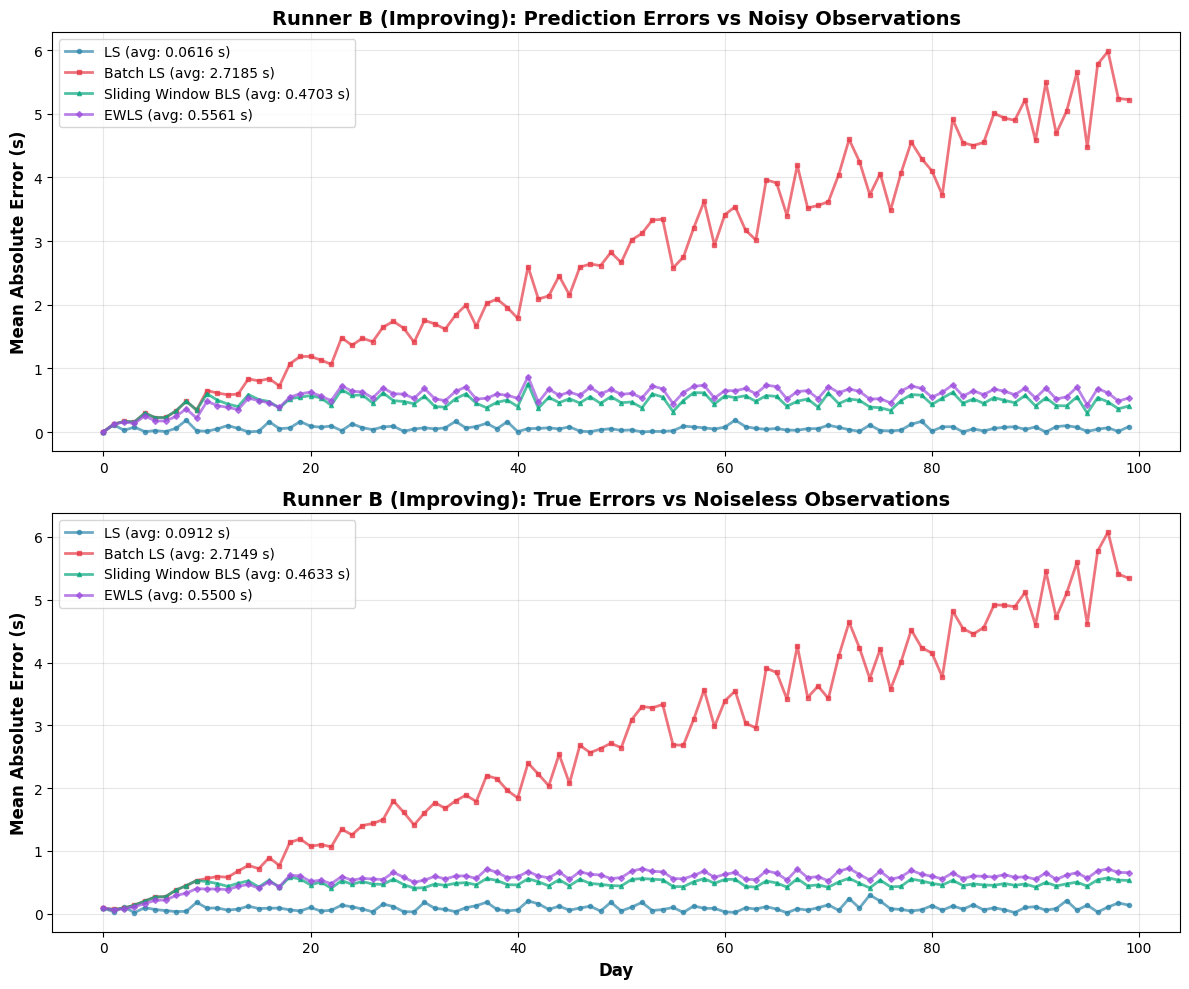

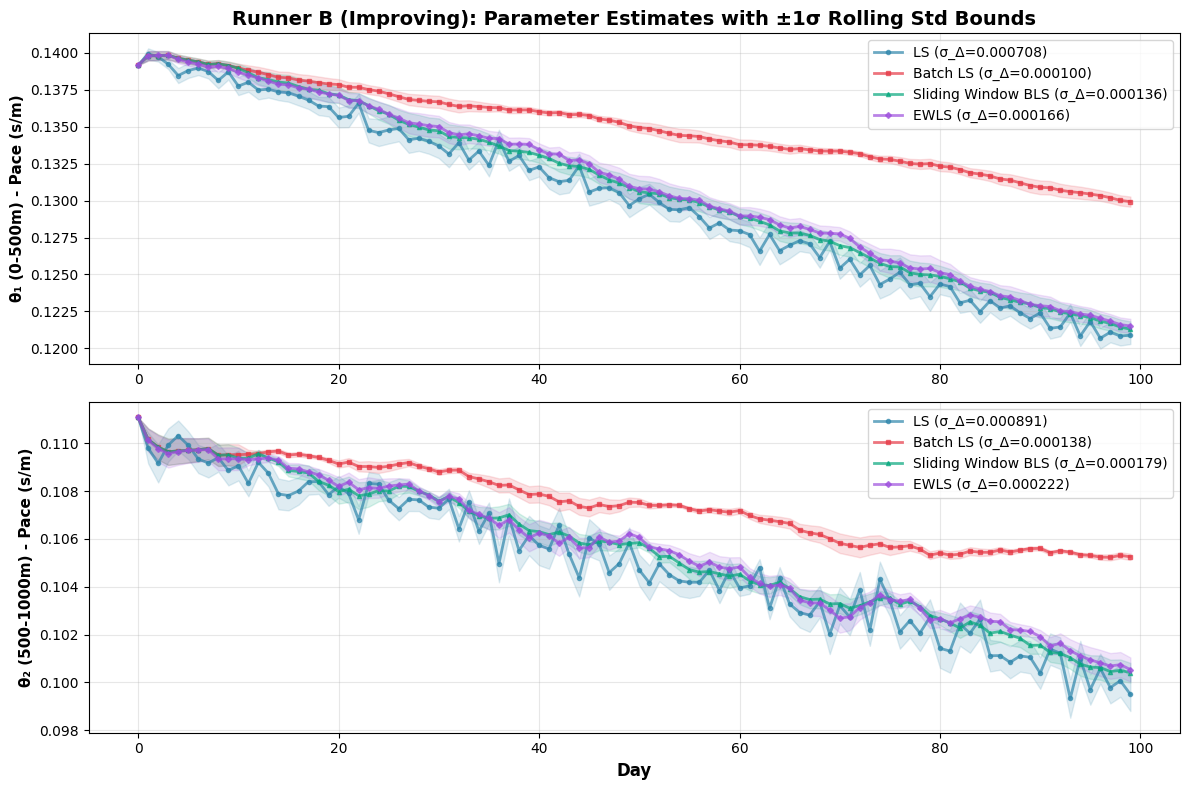

In [16]:
# Setup
num_days = 100

# Create estimators
estimators_B = {
    'LS': LeastSQ(),
    'Batch LS': BatchLeastSQ(),
    'Sliding Window BLS': SlidingBatchLeastSQ(m_window_size=10),
    "EWLS": ExpWeightedLeastSQ(EWLS_lambda=0.85),
}
# Run analysis for Runner B
results_B = run_estimation_analysis(
    runner=runner_B,
    estimators_dict=estimators_B,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

### Analysis for Runner B between LS, BLS, sliding window BLS, EWLS

1. These perform better than BLS, but still less accurate than LS!

    - While LS tracks the evolving trend well, it's **noisy** because it estimates parameters independently each day using only that day's observations, making it hard to trust any single day's estimate.

2. Why EWLS and Sliding Window BLS are Better

    - Both methods **smooth over multiple days** to reduce estimation variance:
    - The tradeoff vs LS is slight lag (bias) in exchange for significantly reduced noise (variance).

2. Which estimator should we use?

    - **Use EWLS** when you want:
      - Smooth, continuous weighting of historical data
      - One tuning parameter (decay factor λ) that's easier to interpret
      - Gradual phase-out of old observations

    - **Use Sliding Window BLS** when you want:
      - Hard cutoff of old data (e.g., "only use last 10 days")
      - Equal weighting of all observations within the window
      - Simpler conceptual model (just "batch over recent history")

**Conclusions**

1. **Sliding Window BLS and EWLS** both achieve more stable parameter estimates by smoothing over multiple days, reducing the high variance seen in daily LS estimates.

2. **Similar performance:** Both methods achieve comparable stability and accuracies when properly tuned.


###Run and compare LS, sliding window batch least squares (SBLS), and EWLS simulation on Runner C - Injured runner

The following simulation applies the following estimators to runner C, who gets injured at day 10 and slowly recovers as days progress

Running estimation analysis for Runner C (Injured)...
Number of days: 100
Estimators: ['LS', 'Sliding Window BLS', 'EWLS']

LS:
  Final θ₁: 0.1301 s/m
  Final θ₂: 0.1036 s/m
  Avg Prediction Error: 0.0657 s
  Avg True Error (vs noiseless obs):   0.0963 s

Sliding Window BLS:
  Final θ₁: 0.1310 s/m
  Final θ₂: 0.1064 s/m
  Avg Prediction Error: 2.0982 s
  Avg True Error (vs noiseless obs):   2.0955 s

EWLS:
  Final θ₁: 0.1317 s/m
  Final θ₂: 0.1065 s/m
  Avg Prediction Error: 2.1193 s
  Avg True Error (vs noiseless obs):   2.1257 s

Generating plots...


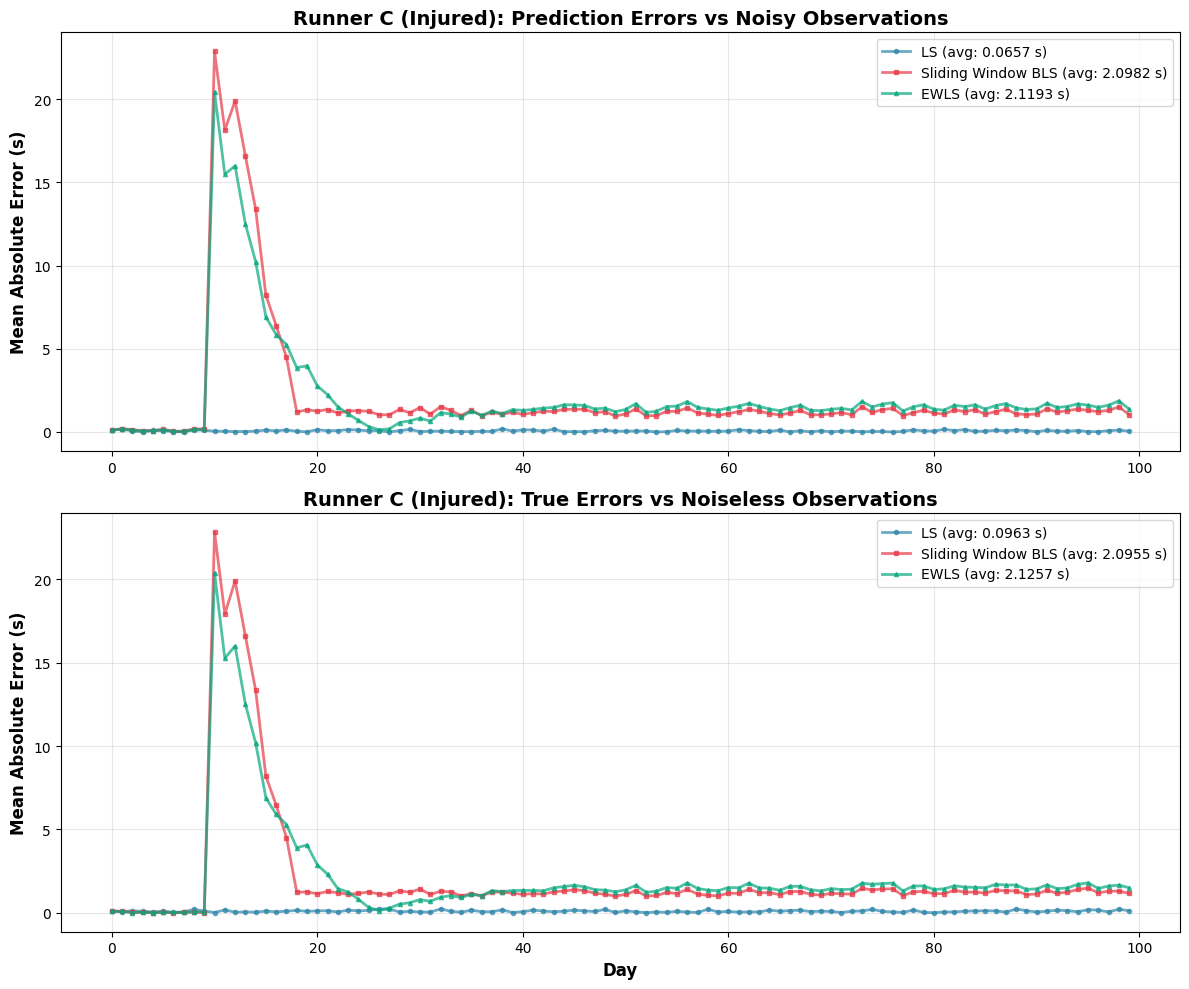

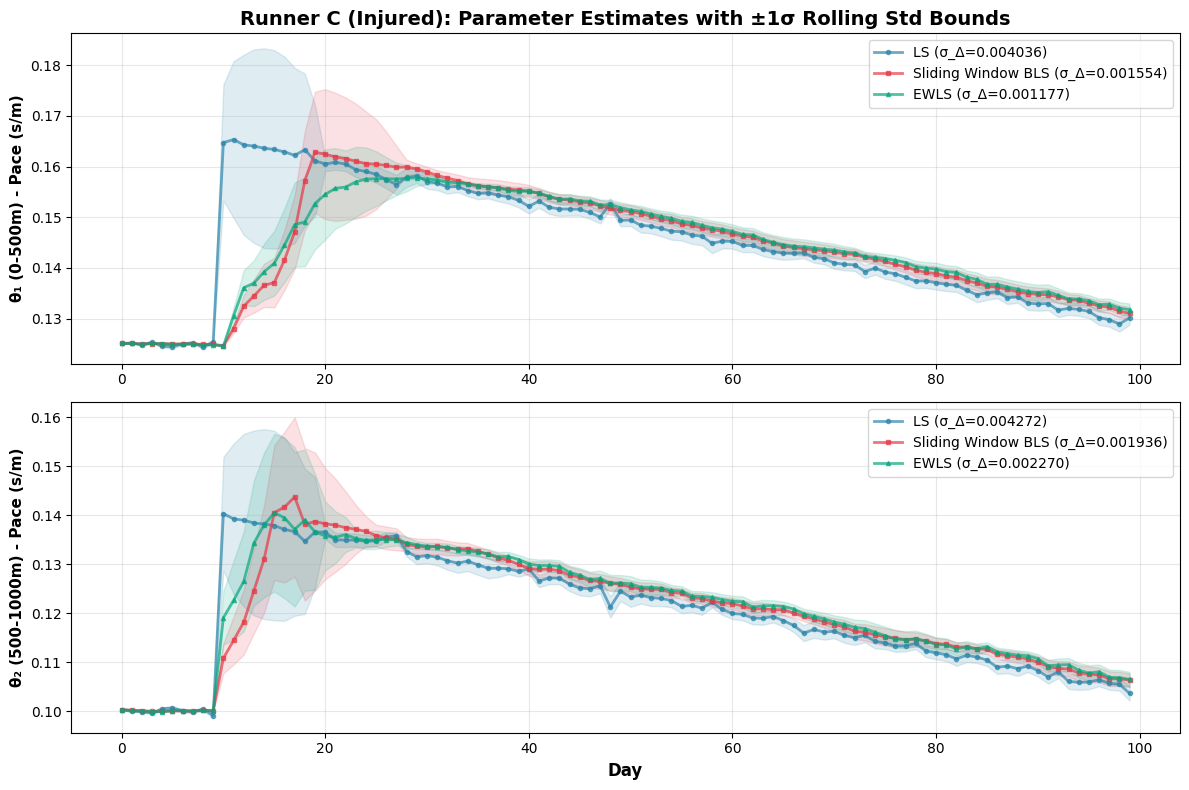

In [17]:
# Setup
num_days = 100

# Create estimators
estimators_C = {
    'LS': LeastSQ(),
    'Sliding Window BLS': SlidingBatchLeastSQ(m_window_size=10),
    "EWLS": ExpWeightedLeastSQ(EWLS_lambda=0.85),
}
# Run analysis for Runner C
results_C = run_estimation_analysis(
    runner=runner_C,
    estimators_dict=estimators_C,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

### Analysis for Runner C between LS, BLS, sliding window BLS, EWLS

1. LS tracks rapid changes better!

    - With abrupt state changes (injury spike, rapid recovery), **LS responds immediately** because it uses only current-day observations.
    - EWLS and Sliding Window BLS **lag during transitions** (days 10-25) because they smooth over outdated historical data that no longer reflects the runner's current state.
    - We can see now that the tradeoff is responsiveness (LS) vs stability (EWLS/Sliding Window).

**Conclusions**

1. **LS excels with rapid state changes** but produces noisier estimates; EWLS/Sliding Window sacrifice responsiveness for stability.

2. **After rapid transitions stabilize**, all methods achieve similar tracking accuracy, making EWLS/Sliding Window preferable for their lower variance for stable periods.

3. **Practical approach**: Combine both—use LS to detect sudden changes, then switch to EWLS/Sliding Window once the system stabilizes for smoother, more reliable ongoing estimates.


## Recursive Least Squares (RLS)

As we saw with Exponentially Weighted Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time "online/data streaming" applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the **inverse of the data correlation matrix**, $(\mathbf{A}^T\mathbf{A})^{-1}$ (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

---
### Recursive Least Squares (RLS) Derivation

At day $n$ the EWLS solution was:

$$\hat{\mathbf{x}}_n = \left(\mathbf{A}_{stack}^T \mathbf{W}_{EWLS} \mathbf{A}_{stack}\right)^{-1} \mathbf{A}_{stack}^T \mathbf{W}_{EWLS} \mathbf{b}_{stack}$$

Let's define:

$$\mathbf{R}_n = \mathbf{A}_{stack}^T \mathbf{W}_{EWLS} \mathbf{A}_{stack} = \sum_{k=1}^{n} \lambda^{n-k} \mathbf{A}_k^T \mathbf{A}_k$$

$$\mathbf{q}_n = \mathbf{A}_{stack}^T \mathbf{W}_{EWLS} \mathbf{b}_{stack} = \sum_{k=1}^{n} \lambda^{n-k} \mathbf{A}_k^T \mathbf{b}_k$$

So the solution becomes:

$$\hat{\mathbf{x}}_n = \mathbf{R}_n^{-1} \mathbf{q}_n$$

where:
- $\mathbf{A}_k \in \mathbb{R}^{J \times m}$ ($J$ coaches/measurements, $m$ parameters)
- $\mathbf{b}_k \in \mathbb{R}^{J \times 1}$ (measurement vector)
- $\mathbf{x} \in \mathbb{R}^{m \times 1}$ (parameter vector)

---

### Establishing Recursive Relations

Using the below manipulations:

$$\mathbf{R}_n = \sum_{k=1}^{n} \lambda^{n-k} \mathbf{A}_k^T \mathbf{A}_k= \lambda \sum_{k=1}^{n-1} \lambda^{(n-1)-k} \mathbf{A}_k^T \mathbf{A}_k + \lambda^{0} \mathbf{A}_n^T \mathbf{A}_n$$

When a new observation arrives, we can update $\mathbf{R}_n$ from $\mathbf{R}_{n-1}$, and similarly for $q_n$:


$$\mathbf{R}_n = \lambda \mathbf{R}_{n-1} + \mathbf{A}_n^T \mathbf{A}_n$$
$$\mathbf{q}_n = \lambda \mathbf{q}_{n-1} + \mathbf{A}_n^T \mathbf{b}_n$$

---

### Applying the Matrix Inversion Lemma

We want to recursively compute $$\mathbf{P}_n = \mathbf{R}_n^{-1}$$ without directly inverting matrices at each step. This represents the parameter estimation error covariance (scaled by noise variance).

Given: $$\mathbf{R}_n = \lambda \mathbf{R}_{n-1} + \mathbf{A}_n^T \mathbf{A}_n$$

The **Matrix Inversion Lemma** (Woodbury identity) states:

$$(\mathbf{B} + \mathbf{C}\mathbf{D}\mathbf{E})^{-1} = \mathbf{B}^{-1} - \mathbf{B}^{-1}\mathbf{C}(\mathbf{D}^{-1} + \mathbf{E}\mathbf{B}^{-1}\mathbf{C})^{-1}\mathbf{E}\mathbf{B}^{-1}$$

Applying this with:
- $\mathbf{B} = \lambda \mathbf{R}_{n-1}$
- $\mathbf{C} = \mathbf{A}_n^T$
- $\mathbf{D} = \mathbf{I}_J$
- $\mathbf{E} = \mathbf{A}_n$

We get:

$$\mathbf{P}_n = \frac{1}{\lambda}\left[\mathbf{P}_{n-1} - \mathbf{P}_{n-1}\mathbf{A}_n^T\left(\lambda \mathbf{I}_J + \mathbf{A}_n \mathbf{P}_{n-1} \mathbf{A}_n^T\right)^{-1} \mathbf{A}_n \mathbf{P}_{n-1}\right]$$

From this formulation of $\mathbf{P}_n$, define the **Kalman gain matrix**:

$$\mathbf{K}_n = \mathbf{P}_{n-1}\mathbf{A}_n^T\left(\lambda \mathbf{I}_J + \mathbf{A}_n \mathbf{P}_{n-1} \mathbf{A}_n^T\right)^{-1}$$

where $\mathbf{I}_J$ is the $J \times J$ identity matrix.

Then the inverse correlation matrix update simplifies to:

$$\mathbf{P}_n = \frac{1}{\lambda}[\mathbf{P}_{n-1} - \mathbf{K}_n \mathbf{A}_n \mathbf{P}_{n-1}]$$

---

### Deriving the Parameter Update

To update the estimated parameter: $\hat{\mathbf{x}}_n$

Starting from $\hat{\mathbf{x}}_n = \mathbf{P}_n \mathbf{q}_n$:

$$\hat{\mathbf{x}}_n = \mathbf{P}_n[\lambda \mathbf{q}_{n-1} + \mathbf{A}_n^T \mathbf{b}_n]$$

Because $\mathbf{q}_{n-1} = \mathbf{R}_{n-1}\hat{\mathbf{x}}_{n-1}$:
\
\
$$\hat{\mathbf{x}}_n = \mathbf{P}_n[\lambda \mathbf{R}_{n-1}\hat{\mathbf{x}}_{n-1} + \mathbf{A}_n^T \mathbf{b}_n]$$

After algebraic manipulation using the recursive form of $\mathbf{P}_n$, this reduces to:

$$\hat{\mathbf{x}}_n = \hat{\mathbf{x}}_{n-1} + \mathbf{K}_n[\mathbf{b}_n - \mathbf{A}_n \hat{\mathbf{x}}_{n-1}]$$

Where $\mathbf{e}_n = \mathbf{b}_n - \mathbf{A}_n \hat{\mathbf{x}}_{n-1}$ is known as the **prediction error** or **innovation**.

---
### The Complete RLS Algorithm

**Initialization:**
- $\hat{\mathbf{x}}_0 = \mathbf{0}$ or prior estimate
- $\mathbf{P}_0 = \delta^{-1}\mathbf{I}_m$ where $\delta$ is a small positive constant

**For each day** $n = 1, 2, 3, \ldots$

1. **Compute innovation covariance and gain matrix:**
   $$\mathbf{S}_n = \lambda \mathbf{I}_J + \mathbf{A}_n \mathbf{P}_{n-1} \mathbf{A}_n^T$$
   $$\mathbf{K}_n = \mathbf{P}_{n-1}\mathbf{A}_n^T \mathbf{S}_n^{-1}$$

2. **Compute prediction error:**
   $$\mathbf{e}_n = \mathbf{b}_n - \mathbf{A}_n \hat{\mathbf{x}}_{n-1}$$

3. **Update parameter estimate:**
   $$\hat{\mathbf{x}}_n = \hat{\mathbf{x}}_{n-1} + \mathbf{K}_n\mathbf{e}_n$$

4. **Update inverse correlation matrix:**
   $$\mathbf{P}_n = \frac{1}{\lambda}[\mathbf{P}_{n-1} - \mathbf{K}_n \mathbf{A}_n \mathbf{P}_{n-1}]$$

---
### Initialization Notes

When initializing RLS, we can set $\hat{\mathbf{x}}_0 = \mathbf{0}$ (or choose your best guess other than 0).However, for $\mathbf{P}_0$, at for prior "day 0", if $\mathbf{R}_0 = 0$. This means for RLS where we track $\mathbf{P}_n$ rather than $\mathbf{R}_n$, $\mathbf{P}_0 = \mathbf{R}_0^{-1}$ is undefined.

The solution is to initialize a large $\mathbf{P}_0 = \delta^{-1}\mathbf{I}_m$ where $\delta$ is small (e.g., $\delta = 0.0001$). This is equivalent to assuming weak prior information - or that our first guess on our parameters is not very certain.

$\mathbf{P}_n = \mathbf{R}_n^{-1}$ represents parameter estimation error covariance (scaled by noise variance). Large $\mathbf{P}_0$ indicates high initial uncertainty. Alternatively, we can run batch LS or EWLS for the first few samples to get prior estimates and $\mathbf{P}_0$, then switch to RLS.

---
### Computation gain from online estimation

RLS's recursive formulation provides significant computational savings over EWLS when computing over multiple days. However, it also moves the computation cost towards the number of measurements per day from the number of parameters.

**Batch EWLS at day n:**
- Complexity: $O(m^2 \cdot nJ + m^3)$ — grows with number of days n and number of parameters (m) dominates

**RLS at day n:**
- Complexity: $O(J^3 + m^2J)$ — constant per day, and number of measurements per day (coaches, J) dominates.


### The Complete RLS Algorithm

**Initialization:**
- $\hat{\mathbf{x}}_n = \mathbf{0}$ or prior estimate
- $\mathbf{P}_n = \delta^{-1}\mathbf{I}$ where $\delta$ is a small positive constant

**For each time step** $n = 1, 2, 3, \ldots$:

1. **Compute gain matrix:**
   $$\mathbf{K}_n = \frac{\mathbf{P}_{n-1}\mathbf{A}_n^T}{\lambda\mathbf{I}  + \mathbf{A}_n \mathbf{P}_{n-1} \mathbf{A}_n^T}$$

2. **Compute prediction error:**
   $$\mathbf{e}_{n-1} = \mathbf{b}_n - \mathbf{A}_n \hat{\mathbf{x}}_{n-1}$$

3. **Update parameter estimate:**
   $$\hat{\mathbf{x}}_{n} = \hat{\mathbf{x}}_{n-1} + \mathbf{K}_{n}\mathbf{e}_{n}$$

4. **Update inverse correlation matrix:**
   $$\mathbf{P}_{n} = \frac{1}{\lambda}[\mathbf{I} - \mathbf{K}_{n} \mathbf{A}_n ]\mathbf{P}_{n-1}$$

---
### Key advantages of RLS over EWLS.

- **Computational advantage**: Avoids recomputing the full matrix inverse; complexity is $O(m^2)$ per iteration where $m$ is the number of parameters, or the dimension of $\mathbf{x}$.
- **Memory advantage**: Avoids storing all past data.
- **Numerical stability**: Use $\lambda < 1$ (e.g., 0.95-0.99) to prevent $\mathbf{P}$ from becoming too small.
- **Initialization**: Use $\mathbf{P_0} = \delta^{-1}\mathbf{I}_m$ where $\delta$ is a small constant.

### Creating a RLS

Below is the RLS equation.
It simply changes the estimator function for LS, updates are tracked via python instance variables (self.variable)

In [18]:
class RecursiveLeastSQ(LeastSQ):
    """
    Recursive Least Squares estimator.
    """
    def __init__(self, RLS_lambda=0.95, P0_scale=1E-3, num_meas=3 , num_params=2):
        super().__init__(num_params=num_params)
        self.RLS_lambda = RLS_lambda
        self.num_meas = num_meas

        self.x0 = np.zeros((self.num_params,1))
        self.P0 = P0_scale**-1*np.eye(self.num_params)

        self.reinitialize()

    def reinitialize(self):
        self.x_est = self.x0
        self.Pn = self.P0

    def estimator(self,A,B):
        """
        Apply the RLS algorithm to update and implement the estimator
        """
        kalman_gain = self.Pn @ A.T @ np.linalg.inv(self.RLS_lambda*np.eye(self.num_meas) + A @ self.Pn @ A.T)

        self.x_est = self.x_est + kalman_gain @ (B - A @ self.x_est)
        I_KA = np.eye(self.num_params) - kalman_gain @ A
        self.Pn = (1./self.RLS_lambda)*I_KA @ self.Pn
        return self.x_est


### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.

Running estimation analysis for Runner B (Improving)...
Number of days: 100
Estimators: ['LS', 'EWLS', 'RLS']

LS:
  Final θ₁: 0.1209 s/m
  Final θ₂: 0.0995 s/m
  Avg Prediction Error: 0.0616 s
  Avg True Error (vs noiseless obs):   0.0912 s

EWLS:
  Final θ₁: 0.1215 s/m
  Final θ₂: 0.1005 s/m
  Avg Prediction Error: 0.5561 s
  Avg True Error (vs noiseless obs):   0.5500 s

RLS:
  Final θ₁: 0.1215 s/m
  Final θ₂: 0.1005 s/m
  Avg Prediction Error: 0.5511 s
  Avg True Error (vs noiseless obs):   0.5448 s

Generating plots...


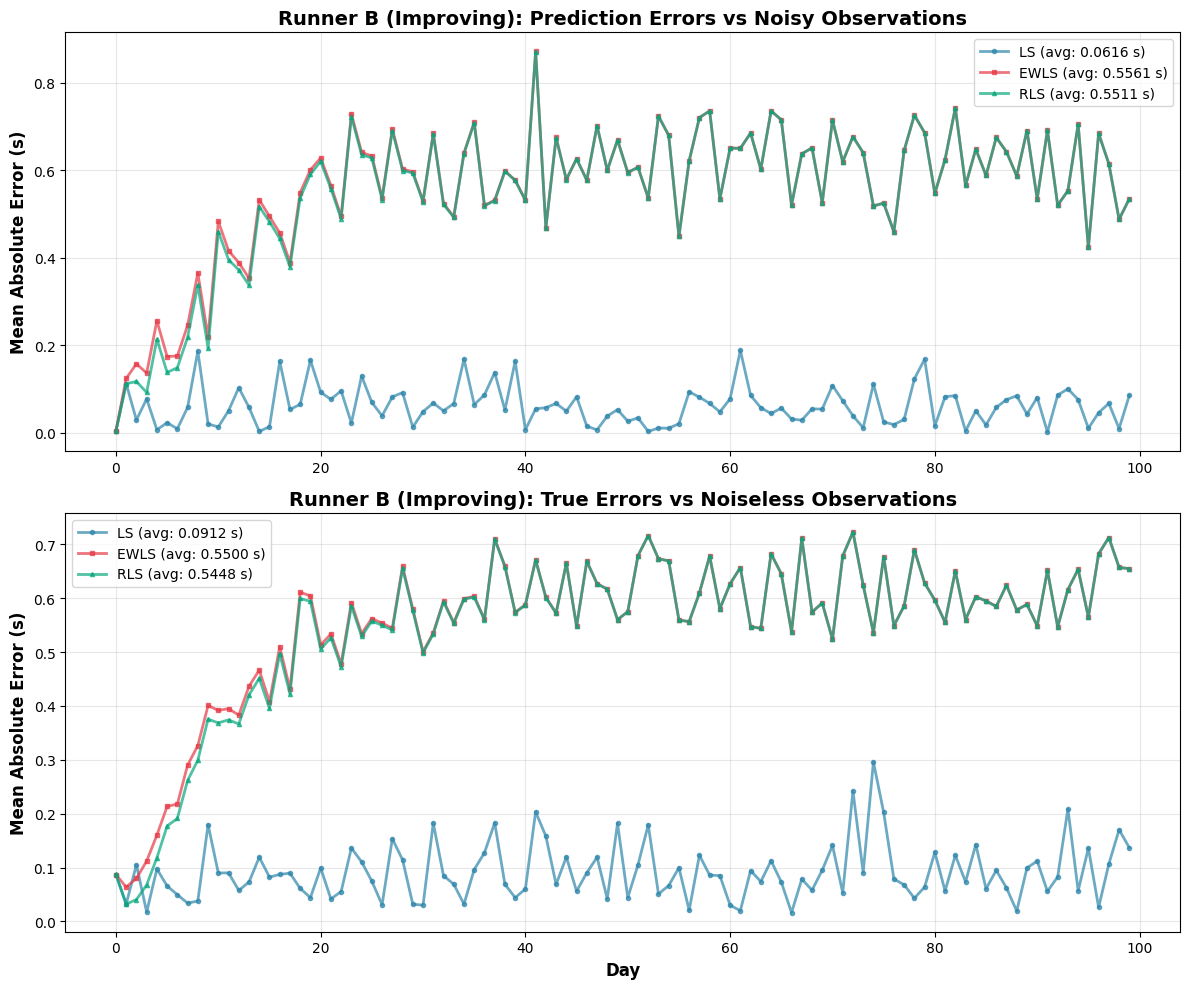

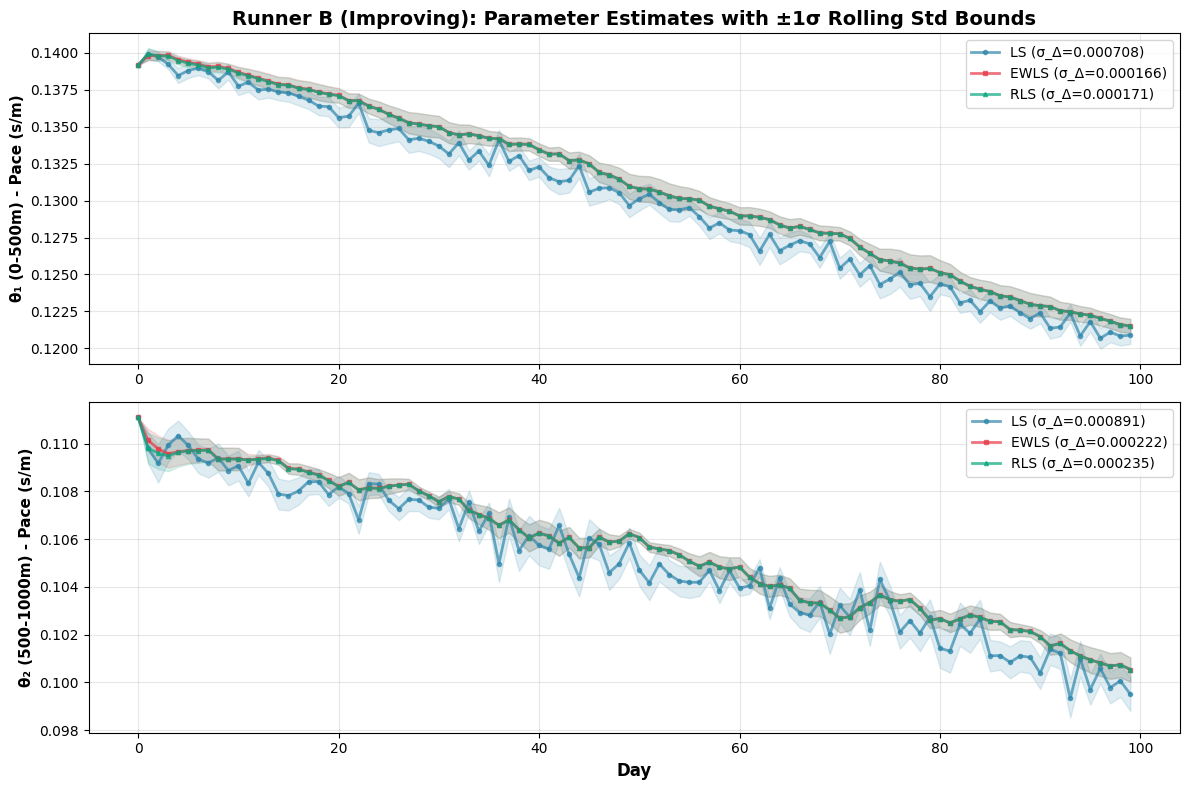

In [19]:
# Setup
num_days = 100

# Create estimators
estimators_B = {
    'LS': LeastSQ(),
    "EWLS": ExpWeightedLeastSQ(EWLS_lambda=0.85),
    "RLS": RecursiveLeastSQ(RLS_lambda=0.85, P0_scale=1E-7, num_meas=3),
}
# Run analysis for Runner B
results_B = run_estimation_analysis(
    runner=runner_B,
    estimators_dict=estimators_B,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

### Brief Analysis for Runner B between EWLS and RLS.

1. EWLS and RLS converges to same results later, but not at the start.

    - RLS and EWLS are mathematically equivalent—they solve the same exponentially weighted least squares problem. However, for RLS, we made an initial guess for our parameters and update that.

**Conclusions**

1. **Similar performance:** Both methods achieve comparable stability and accuracies when properly tuned.